---
title: "van 't Riet's k_L a correlation: a branched power law, what its data can and cannot resolve, and the measuring method it outgrows"
description: "Two constants for coalescing water and two for ionic solutions. On the review's own printed numbers the ionic v_s exponent is inside its own error bar, the ion enhancement falls below the range the review expects for it in one corner of the window, and eq. 9 predicts mass transfer fast enough that the well-mixed-gas assumption behind eq. 2 under-reports k_L a by 19 % (pure water) to 45 % (ionic) in this page's own transient."
categories: [sec:A, struct:S3, struct:S4, tier:T1, data:tier6, phase:gas-liquid]
date: 2026-08-05
---

# van 't Riet's k_L a correlation for stirred gas-liquid vessels

**Catalog ID:** `A3.7` · **Structures:** `S3` (1-D steady convection with a
linear sink), `S4` (1-D transient PDE coupled to a lumped phase) · **Tier:** T1

Two numbers predict volumetric oxygen transfer in a stirred vessel: the power
the impeller puts into the liquid, and the superficial gas velocity. That is
the claim, and it has survived since 1979 as the default sizing correlation for
aerated fermenters. It comes in two versions, one for water and one for water
with salt in it, and they are not small perturbations of each other.

This page implements both branches, asks what the review's own printed numbers
can and cannot decide about the four exponents in them, and then uses pymrm to
put a number on the one assumption the review warns about in words and never
quantifies.

## Background

**This is a review, and most of what is in it is somebody else's.** The title
says so: *Review of Measuring Methods and Results in Nonviscous Gas-Liquid Mass
Transfer in Stirred Vessels*. Its Literature Cited runs to a column and a half,
its five figures compile other people's measurements, and the running text spends
most of its length judging measuring methods rather than reporting results.

Two things in it are van 't Riet's own, and they are what this page is about.
He correlates the whole compiled body of data with

$$k_\mathrm{L}A = K\left(\frac{P}{V}\right)^{\alpha} v_\mathrm{s}^{\beta},$$

and he insists the constants must be **branched** — one set for water and one
set for strong ionic solutions, because ions suppress bubble coalescence and the
interfacial area is a different quantity in the two cases. That branching is
what makes the correlation worth a page: a single power law with the wrong
constants is not merely imprecise here, it is the wrong physics.

**Why a stirred tank shows up in a section about mass transfer coefficients.**
The vessel is not modelled at all in the review. What is modelled is the
*measurement*: the dynamic gassing-out experiment assumes a perfectly mixed gas
phase, and the review returns to that assumption four separate times — saying it
*"can be dangerous in vessels with a tank height $H_\mathrm{t}$ vs. diameter $T$
ratio $H_\mathrm{t}/T \gg 1$"*, that *"plug flow for the gas phase is a more
accurate model"* there, and twice more that the reservation must be carried into
the geometry results. That is a
convection-with-a-linear-sink problem coupled to a lumped liquid — `S3` plus
`S4` — and it is the part pymrm can carry.

## The published model

### What was read, and from where

`AGENTS.md`'s reprint rule applies in full here, because a review is exactly the
case it was written for. The distinction this page keeps:

| | |
| --- | --- |
| **`reference`** | van 't Riet, K., *Ind. Eng. Chem. Process Des. Dev.* **18**(3) 357–364 (1979), [doi:10.1021/i260071a001](https://doi.org/10.1021/i260071a001) |
| **`reference_read_from`** | the same document — for eqs. 1–9, which are printed there in full |
| **`origin_not_consulted`** | Zlokarnik (1970) for the exponent 0.2; Van de Sande (1974) and Linek (1972) for the two probe-response criteria; Lee & Meyrick (1970), Machón et al. (1977), Reith & Beek (1968), Smith et al. (1977), Robinson & Wilke (1973, 1974), Calderbank (1958), Valentin & Preen (1962), Kawecki et al. (1967), Hassan & Robinson (1977), Topiwala & Hamer (1973) — every one of these supplies data or a number the review reports, and **none of the originals is on disk or was consulted** |

**Eqs. 8 and 9 are van 't Riet's own.** He introduces eq. 8 with *"The data can
be correlated according to"* and eq. 9 with *"When the $v_\mathrm{s}^{0.2}$ is
taken into account, one obtains from Figure 4"*. So the review does not merely
mention this correlation, it **carries and states** it — the `E1.1` test that
killed a case earlier in this queue is passed here, and passed on the strongest
form of the test, because the result *originates* in this document.

The dataset `vant-riet-1979-printed-numbers.csv` carries an `origin` column for
exactly this reason: every number this page reads is labelled with whose result
it is.

### The correlation

$$k_\mathrm{L}A = 2.6\times10^{-2}\left(\frac{P}{V}\right)^{0.4} v_\mathrm{s}^{0.5}
\quad\text{(eq. 8, pure water)}$$

$$k_\mathrm{L}A = 2.0\times10^{-3}\left(\frac{P}{V}\right)^{0.7} v_\mathrm{s}^{0.2}
\quad\text{(eq. 9, strong ionic solutions)}$$

with $k_\mathrm{L}A$ in s⁻¹, $P/V$ in W m⁻³ and $v_\mathrm{s}$ in m s⁻¹. Both
are printed with $500 < P/V < 10\,000$ W m⁻³ and *"accurate for 20–40 %"*; eq. 8
adds *"volume measured up to 2600 L"* and eq. 9 *"2 < V < 4400 L"*.

### The measurement being modelled

The dynamic gassing-out method (eq. 2, the review's own numbering):

$$\frac{\mathrm{d}C_\mathrm{L}}{\mathrm{d}t} = k_\mathrm{L}A\!\left(\frac{C_\mathrm{G}}{H} - C_\mathrm{L}\right)
\;\Longrightarrow\;
k_\mathrm{L}A = \frac{\ln\dfrac{C_\mathrm{G}/H - C_\mathrm{L}(t_1)}{C_\mathrm{G}/H - C_\mathrm{L}(t_2)}}{t_2 - t_1}$$

**$C_\mathrm{G}$ is a constant in eq. 2.** That is the well-mixed-gas
assumption, and it is what the last third of this page tests. The review states
the constraint that goes with it (eq. 3),

$$\tau_\mathrm{G} = \frac{\epsilon V}{v_\mathrm{s}\cdot\frac{1}{4}\pi T^{2}}
                  = \frac{\epsilon H_\mathrm{t}}{v_\mathrm{s}},$$

*"If this value is not much smaller than $1/k_\mathrm{L}A$, measuring results
can be affected a good deal"*, and says the trouble grows with vessel diameter
and at low $v_\mathrm{s}$ — but never turns any of that into a number.

### Two printed defects, recorded and not repaired

1. The sentence under eq. 7 reads *"where $N$ = stirrer diameter"*. The
   Nomenclature gives $N$ = stirrer speed (s⁻¹) and $D$ = stirrer diameter (m).
2. **Four of the five figure legends cite the drawn correlation by an equation
   number one lower than the text does — and the fifth cites none at all.**
   Figures 1–3 print `CORRELATION EQUATION (7)` where the text says the broken
   lines are eq. 8's; Figure 4 prints `CORRELATION EQUATION (8)` for both of
   its lines, on the very figure from which eq. 9 is derived. Figure 5's legend
   names the liquids (`a. PURE WATER 0.5` … `f. IONIC SOLUTION 4`) and cites no
   equation number, so the offset appears in exactly the four figures whose
   legend cites one. Eq. 7 has no numerical constants in it and cannot be
   drawn at all. The `label_says_equation` column of the legend dataset carries
   the printed numbers — empty for Figure 5 — so a reader can check the offset
   without the paper.

## Parameters and assumptions

**Printed, and used as printed.** The two prefactors, the four exponents, both
validity windows, the 20–40 % accuracy claim, $\alpha$ and $\beta$ literature
ranges (0.4–1 and 0–0.7 generally; 0.35–0.5 and 0.3–0.6 for pure water), the
electrode ceiling $k_\mathrm{L}A = 0.1$ s⁻¹ with $\tau_\mathrm{p}$ = 2 or 3 s,
the two probe-error criteria, the expectation that ions raise $k_\mathrm{L}A$
by 2–10 times, $k_\mathrm{L} = 4\times10^{-4}$ m s⁻¹, and $0.5 < T/H < 1.5$.

**Printed inside the figures, and used as printed.** The legend tables of
Figures 1–5 give the superficial gas velocities at which van 't Riet chooses to
exhibit his own correlations (Figure 5: 0.5, 2 and 4 cm s⁻¹ for *both* branches)
and the vessel volumes of every data set (2.5 L to 5100 L). **These are typeset
tables that happen to sit inside plot frames.** Reading them is transcription,
not digitisation — nothing on this page is traced, no axis is calibrated, and no
marker position is extracted.

**Not printed anywhere in the review, and supplied here.** Three quantities,
all of which the gas-depletion calculation needs and none of which the review
states:

| symbol | value used | what it is, and why |
| --- | --- | --- |
| $H$ | 30 | Henry constant of eq. 1, $C_\mathrm{G}/H$ being the liquid-side equilibrium concentration. **Not printed and no source for it is on disk.** Swept over 20–40 in Validation; the headline is also reported in the $H$-free form $N_\mathrm{G}H$ |
| $\epsilon$ | 0.10 | gas holdup. It **cancels** from the governing group except through $(1-\epsilon)$, so it is a weak input; swept in the break table |
| $H_\mathrm{t}/T$ | 1.0 | centre of the review's own printed window $0.5 < T/H < 1.5$; both extremes are swept |

The vessel height then follows from the review's **own** eq. 3 geometry,
$V = \tfrac14\pi T^2 H_\mathrm{t}$, so nothing about the vessel is guessed once
a printed volume is chosen.

**Scoped out, explicitly.** Figures 1–5 hold the only measurements in the
review. Extracting them needs a maintainer overlay review and **no maintainer is
available**, so they are not digitised and nothing on this page rests on them.
That decision is what makes this page a *reproduction, not a validation*, and it
is stated again where it matters.

## The data

Three CSVs, each with a provenance sidecar carrying a `columns:` block.

| file | what it is |
| --- | --- |
| `vant-riet-1979-correlations.csv` | eqs. 8 and 9: prefactors, exponents, validity windows, accuracy claim |
| `vant-riet-1979-printed-numbers.csv` | every other number the review prints as text, each tagged with **whose result it is** |
| `vant-riet-1979-figure-legends.csv` | the legend tables of Figures 1–5 — printed text, not extracted curve data |

Everything was read from **native-resolution** page renders.
`pdfimages -list` reports all 24 embedded images as CCITT-G4 bilevel at
**300 × 300 ppi**, so `pdftoppm -r 300` is the correct render and 600 dpi would
be interpolation. Every numeral was then re-read from a tight crop: the scan's
OCR text layer returns eq. 8 as `khA = 2.6 X 10-^)°>` and detaches eq. 9's 0.7
exponent onto its own line, so neither equation is readable from it at all.

**No other page's dataset is loaded**, so the cross-page rule does not bite
here. `A3.6` (Calderbank & Moo-Young) is published and `A3.8` (Onda) is staged
in the same queue; Calderbank's 1958 and 1959 papers supply three of the data
sets in Figures 1–3 of this review, and if a comparison between his
$k_\mathrm{L}$ correlation and van 't Riet's $k_\mathrm{L}A$ is worth making,
**`A3.6` should own it** — it has Calderbank's own definitions, which this page
does not.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml


In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gallery_utils import load_data, report_agreement

PAGE = "A3.7-vant-riet-kla"
np.random.seed(20260805)          # nothing on this page is stochastic; seeded anyway
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
corr = load_data("vant-riet-1979-correlations.csv", page=PAGE)
nums = load_data("vant-riet-1979-printed-numbers.csv", page=PAGE).set_index("key")
legs = load_data("vant-riet-1979-figure-legends.csv", page=PAGE)

print(corr.to_string(index=False))
print()
# the review's own numbers, and whose they are
for k in ["kla_electrode_ceiling", "linek_margin", "probe_tau_lo",
          "ion_enhancement_lo", "ion_enhancement_hi", "accuracy_lo_pct",
          "accuracy_hi_pct", "zlokarnik_vs_exponent", "TH_ratio_lo", "TH_ratio_hi"]:
    r = nums.loc[k]
    print(f"  {k:24s} = {r['value']:>8} {r['unit']:5s}  origin: {r['origin']}")


 equation     branch     K  alpha  beta  pv_min_W_m3  pv_max_W_m3  V_min_L  V_max_L  accuracy_pct_lo  accuracy_pct_hi figures
        8 pure_water 0.026    0.4   0.5          500        10000      NaN     2600               20               40   1;2;3
        9      ionic 0.002    0.7   0.2          500        10000      2.0     4400               20               40     4;5

  kla_electrode_ceiling    =      0.1 1/s    origin: vant_riet_1979
  linek_margin             =      5.0 -      origin: Linek_1972
  probe_tau_lo             =      2.0 s      origin: vant_riet_1979
  ion_enhancement_lo       =      2.0 -      origin: vant_riet_1979
  ion_enhancement_hi       =     10.0 -      origin: vant_riet_1979
  accuracy_lo_pct          =     20.0 %      origin: vant_riet_1979
  accuracy_hi_pct          =     40.0 %      origin: vant_riet_1979
  zlokarnik_vs_exponent    =      0.2 -      origin: Zlokarnik_1970
  TH_ratio_lo              =      0.5 -      origin: vant_riet_1979
  TH_ratio_hi

In [3]:
# The evaluation points are the review's own: Figure 5 draws BOTH branches at
# the same three superficial gas velocities, so no choice is made here.
f5 = legs[legs.figure == 5]
VS_FIG5 = [float(v) for v in sorted(f5.vs_m_s.unique())]
print("Figure 5 exhibits both branches at v_s =", VS_FIG5, "m/s")

# vessel volumes, from the legends of Figures 1-4
V_PRINTED = sorted({float(v) for cell in legs.volume_L.dropna()
                    for v in str(cell).split(";")})
print("vessel volumes printed in the legends (L):", V_PRINTED)

# the printed off-by-one in the figure legends, straight out of the data
off = legs.dropna(subset=["label_says_equation"])[
    ["figure", "liquid", "entry", "label_says_equation"]]
text_says = {1: 8, 2: 8, 3: 8, 4: 9}
off = off.assign(text_says=off.figure.map(text_says),
                 offset=lambda d: d.label_says_equation - d.figure.map(text_says))
print()
print(off.to_string(index=False))
n5 = legs[(legs.figure == 5)].label_says_equation.notna().sum()
print(f"\nlegend cites the equation number {int(off.offset.unique()[0]):+d} "
      f"relative to the text, in all {off.figure.nunique()} figures whose legend "
      f"cites one; Figure 5's legend cites {n5} equation numbers - it names the "
      f"liquids instead")


Figure 5 exhibits both branches at v_s = [0.005, 0.02, 0.04] m/s
vessel volumes printed in the legends (L): [2.5, 5.0, 21.0, 40.0, 70.0, 90.0, 180.0, 1360.0, 4400.0, 5100.0]

 figure     liquid entry  label_says_equation  text_says  offset
      1 pure_water     C                  7.0          8    -1.0
      2 pure_water     C                  7.0          8    -1.0
      3 pure_water     C                  7.0          8    -1.0
      4      ionic    C1                  8.0          9    -1.0
      4      ionic    C2                  8.0          9    -1.0

legend cites the equation number -1 relative to the text, in all 4 figures whose legend cites one; Figure 5's legend cites 0 equation numbers - it names the liquids instead


## PyMRM implementation

Two objects. The first is the correlation itself — five lines, no discretisation
in it, and pymrm adds nothing to it whatever. The second is the vessel model,
which is where pymrm does the work.

**The vessel model.** Gas rises in plug flow through a well-mixed liquid:

$$\epsilon\frac{\partial C_\mathrm{G}}{\partial t}
  + \frac{\partial (v_\mathrm{s}C_\mathrm{G})}{\partial z}
  = -(1-\epsilon)\,k\!\left(\frac{C_\mathrm{G}}{H}-C_\mathrm{L}\right),
\qquad
\frac{\mathrm{d}C_\mathrm{L}}{\mathrm{d}t}
  = k\!\left(\frac{\langle C_\mathrm{G}\rangle}{H}-C_\mathrm{L}\right).$$

The liquid equation is the review's eq. 2 with $C_\mathrm{G}$ replaced by its
column mean, so $k$ here *is* the review's $k_\mathrm{L}A$, on a liquid-volume
basis, and setting $\langle C_\mathrm{G}\rangle = C_\mathrm{G,in}$ recovers
eq. 2 exactly.

The gas is fed at $z=0$, where the sparger is. The outward normal points in
$-z$ there, so `{"a": 0, "b": 1, "d": C_in}` is the Dirichlet inlet; at the
outlet upwind takes the interior cell and the right-hand dict never enters the
flux. `nu = 0` in `construct_div` — the column has a constant cross-section.

**One group governs the whole thing.** A gas parcel spends
$\tau_\mathrm{G} = \epsilon H_\mathrm{t}/v_\mathrm{s}$ in the column (the
review's eq. 3) and is stripped at $(1-\epsilon)k/\epsilon$ per unit gas volume;
a driving force $u$ in liquid units is $Hu$ in gas units, so

$$\boxed{\;N_\mathrm{G}
  = \frac{(1-\epsilon)\,k\,\tau_\mathrm{G}}{\epsilon H}
  = \frac{(1-\epsilon)\,k\,H_\mathrm{t}}{v_\mathrm{s}H}\;}$$

and the holdup cancels except through $(1-\epsilon)$. **This is not the
review's criterion.** The review compares $\tau_\mathrm{G}$ with
$1/k_\mathrm{L}A$, which is $N_\mathrm{G}$ *without* the factor
$(1-\epsilon)/(\epsilon H)$ — a factor of order $1/3$ for oxygen in water at
$\epsilon = 0.1$. The review's rule of thumb is therefore conservative, and by
how much depends on a quantity ($H$) it never prints.

In [4]:
import numpy as np
import pandas as pd

# --- the two branches, exactly as printed (eqs. 8 and 9) ---------------
CORR = {
    "pure_water": dict(eq=8, K=2.6e-2, alpha=0.4, beta=0.5),
    "ionic":      dict(eq=9, K=2.0e-3, alpha=0.7, beta=0.2),
}
PV_LO, PV_HI = 500.0, 10000.0          # printed for BOTH branches
ACC_LO, ACC_HI = 0.20, 0.40            # "accurate for 20-40%", both branches

# ONE grid, used by every map, every reported metric and every break-table row,
# so a number in the prose cannot drift from the number a cell prints. Its
# bounds are printed values: P/V from both equations' validity statements, v_s
# from Figure 5's legend (0.5-4 cm/s) and, for the widest span, Figure 4's two
# drawn correlation lines C1 and C2 (0.45 and 4.7 cm/s).
PV_GRID = np.geomspace(PV_LO, PV_HI, 400)
VS_GRID = np.geomspace(0.005, 0.040, 400)        # Figure 5's span, both branches
VS_GRID_WIDE = np.geomspace(0.0045, 0.047, 400)  # Figure 4's C1..C2 span

def kla(pv, vs, branch=None, K=None, alpha=None, beta=None):
    """k_L*A [1/s] from P/V [W/m3] and v_s [m/s]. Eq. 6 with the branch's constants."""
    if branch is not None:
        c = CORR[branch]
        K, alpha, beta = c["K"], c["alpha"], c["beta"]
    return K * np.asarray(pv, float) ** alpha * np.asarray(vs, float) ** beta

def crossing_pv(vs_pure, vs_ionic, C=CORR):
    """P/V at which the pure-water curve at vs_pure meets the ionic curve at vs_ionic.

    Setting eq. 8 = eq. 9 and solving: the exponents differ, so there is exactly
    one positive root and it is available in closed form.
    """
    p, i = C["pure_water"], C["ionic"]
    num = p["K"] * vs_pure ** p["beta"]
    den = i["K"] * vs_ionic ** i["beta"]
    return (num / den) ** (1.0 / (i["alpha"] - p["alpha"]))

def refit_cost(exp_alt, exp_ref, lo, hi, which):
    """How much a different exponent costs, once the prefactor is re-fitted.

    The prefactor is re-fitted so the altered correlation is EXACT at the
    geometric centre of the printed window. What is returned is the largest
    fractional departure from the printed correlation anywhere in that window -
    i.e. the most a reader could be misled by using `exp_alt` instead.

    This is the quantity van 't Riet asks for and does not compute: "Relatively
    much store is set by the values of alpha and beta. To what extent these can
    be varied without affecting the outcome significantly ...".
    """
    centre = np.sqrt(lo * hi)
    ends = np.array([lo, hi]) / centre
    factors = ends ** (exp_alt - exp_ref)
    return float(np.max(np.abs(factors - 1.0))), factors

In [5]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve, splu
from pymrm import construct_div, construct_convflux_upwind

# ---------------------------------------------------------------------
# Gas plug flow up the vessel, liquid perfectly mixed.
#
#   gas    (per unit DISPERSION volume, holdup eps, superficial velocity v_s):
#          eps dC_G/dt + d(v_s C_G)/dz = -(1-eps) k (C_G/H - C_L)
#   liquid (per unit LIQUID volume, so that it reduces to the review's eq. 2):
#          dC_L/dt = k (<C_G>/H - C_L),        <C_G> = (1/H_t) int_0^{H_t} C_G dz
#
# k is k_L*A on a liquid-volume basis, matching eq. 2. H is the Henry constant
# of the review's eq. 1, C_G/H being the liquid-side equilibrium concentration.
# Boundary condition: gas enters at z = 0, where the sparger is, and leaves at
# z = H_t. The outward normal points in -z at the inlet, so {a:0, b:1, d:C_in}
# is C_G = C_in there; at the outlet upwind takes the interior value and the
# right-hand dict never enters the flux.
# nu = 0 in construct_div: the column has a constant cross-section.
# ---------------------------------------------------------------------

def _operators(n, H_t, v_s, nu=0, inlet_top=False, dirichlet_both=False, C_in=1.0,
               return_flux=False):
    shape, x_f = (n, 1), np.linspace(0.0, H_t, n + 1)
    if inlet_top:                       # BREAK ROW: gas fed at the top
        bc, v = ({"a": 1.0, "b": 0.0, "d": 0.0}, {"a": 0.0, "b": 1.0, "d": C_in}), -v_s
    elif dirichlet_both:                # BREAK ROW: over-specified
        bc, v = ({"a": 0.0, "b": 1.0, "d": C_in}, {"a": 0.0, "b": 1.0, "d": C_in}), v_s
    else:
        bc, v = ({"a": 0.0, "b": 1.0, "d": C_in}, {"a": 1.0, "b": 0.0, "d": 0.0}), v_s
    Conv, conv_bc = construct_convflux_upwind(shape, x_f, bc=bc, v=v)
    Div = construct_div(shape, x_f, nu=nu)
    g = np.asarray((Div @ conv_bc).todense()).reshape(-1)
    if return_flux:
        return (Div @ Conv), g, Conv, np.asarray(conv_bc.todense()).reshape(-1)
    return (Div @ Conv), g

def stripping_number(k, H_t, v_s, eps, Henry):
    """N_G: how many e-foldings of gas-side driving force the column strips.

    A gas parcel spends tau_G = eps*H_t/v_s in the column (the review's eq. 3)
    and loses oxygen at (1-eps) k (C_G/H - C_L) per unit dispersion volume, i.e.
    at (1-eps) k / eps per unit GAS volume. A driving force u in liquid units is
    H*u in gas units, so

        N_G = (1-eps) k tau_G / (eps H) = (1-eps) k H_t / (v_s H)

    and the gas holdup cancels except through (1-eps). Note what this is NOT:
    the review's own criterion for this problem is tau_G vs 1/(k_L A), which
    omits the factor (1-eps)/(eps H) entirely.
    """
    return (1.0 - eps) * k * H_t / (v_s * Henry)

def phi_closed(N_G):
    """Mean driving force / inlet driving force for a quasi-steady gas column.

    Closed form, derived independently of any discretisation: with C_L frozen
    the gas driving force decays exponentially along z, so its column mean is
    (1 - exp(-N_G))/N_G. The apparent k_L*A that eq. 2 returns is phi times the
    true one.
    """
    N_G = np.asarray(N_G, float)
    return np.where(N_G < 1e-8, 1.0 - N_G / 2.0, (1.0 - np.exp(-N_G)) / np.where(N_G == 0, 1.0, N_G))

def phi_pymrm(n, H_t, v_s, eps, k, Henry, C_in=8.5, C_L_frac=0.3,
              nu=0, phase=None, sign=+1.0, **bckw):
    """Same quantity, from the pymrm operators. Quasi-steady gas at frozen C_L."""
    ph = (1.0 - eps) if phase is None else phase
    C_L = C_L_frac * C_in / Henry
    L, g = _operators(n, H_t, v_s, nu=nu, C_in=C_in, **bckw)
    A = L + sp.eye(n, format="csc") * (sign * ph * k / Henry)
    b = -g + sign * ph * k * C_L
    c = spsolve(A.tocsc(), b)
    return float((c.mean() / Henry - C_L) / (C_in / Henry - C_L))

def gassing_out(n, nt, t_end, H_t, v_s, eps, k, Henry, C_in=8.5,
                gas_initially_inert=False, nu=0, phase=None, sign=+1.0, **bckw):
    """Full transient: the dynamic gassing-out experiment, implicit Euler.

    Linear, so one LU factorisation serves every step. Returns t, C_L(t) and the
    cumulative oxygen that crossed the interface, for the mass balance.
    """
    ph = (1.0 - eps) if phase is None else phase
    L, g, Conv, cbc = _operators(n, H_t, v_s, nu=nu, C_in=C_in, return_flux=True, **bckw)
    dt, w = t_end / nt, np.full(n, 1.0 / n)
    I = sp.eye(n, format="csc")
    A = sp.bmat([[eps / dt * I + L + (sign * ph * k / Henry) * I,
                  sp.csc_matrix(-sign * ph * k * np.ones((n, 1)))],
                 [sp.csc_matrix(-(k / Henry) * w.reshape(1, n)),
                  sp.csc_matrix([[1.0 / dt + k]])]], format="csc")
    lu = splu(A.tocsc())
    C = np.zeros(n) if gas_initially_inert else np.full(n, C_in)
    C_L, ts, CLs, Cs = 0.0, [0.0], [0.0], [C.copy()]
    net_in = 0.0        # cumulative convective input per unit dispersion volume
    for m in range(nt):
        sol = lu.solve(np.concatenate([eps / dt * C - g, [C_L / dt]]))
        C, C_L = sol[:n], sol[n]
        # the OPERATOR'S OWN face fluxes, not a hand-written v_s*C_N: pymrm's
        # Neumann outflow boundary extrapolates to the face rather than taking
        # the upwind cell, so the two differ by O(1/n). See Validation.
        f = np.asarray(Conv @ C.reshape(-1, 1)).ravel() + cbc
        net_in += (f[0] - f[-1]) / H_t * dt
        ts.append((m + 1) * dt); CLs.append(C_L); Cs.append(C.copy())
    C0 = np.zeros(n) if gas_initially_inert else np.full(n, C_in)
    balance = abs(eps * (C - C0).mean() + (1.0 - eps) * C_L - net_in) / max(abs(net_in), 1e-300)
    return np.array(ts), np.array(CLs), np.array(Cs), float(balance)

def fit_eq2(ts, CLs, C_star, f1=0.2, f2=0.8):
    """What an experimenter gets by applying the review's eq. 2 to a C_L trace.

    Eq. 2 is  k_L*A = ln[(C_G/H - C_L(t1)) / (C_G/H - C_L(t2))] / (t2 - t1),
    with C_G taken as the INLET gas composition - which is the well-mixed-gas
    assumption this page is testing. t1 and t2 are placed where C_L crosses f1
    and f2 of saturation. f1 = 0.2 and f2 = 0.8 are CHOSEN - the review
    prescribes no window - and on the ionic branch the choice matters, because
    the response is not a single exponential there. Validation prints the sweep
    over (0.1, 0.9), (0.2, 0.8) and (0.3, 0.7).
    """
    t1, t2 = np.interp([f1 * C_star, f2 * C_star], CLs, ts)
    c1, c2 = np.interp([t1, t2], ts, CLs)
    return float(np.log((C_star - c1) / (C_star - c2)) / (t2 - t1))

def lagrangian(M, nt, t_end, H_t, v_s, eps, k, Henry, C_in=8.5,
               gas_initially_inert=False):
    """INDEPENDENT ROUTE. Integrate along the gas characteristics.

    No spatial operator, no pymrm matrix, no finite-volume cell. Every gas
    parcel is tracked by its age a in [0, tau_G]; the column mean is an average
    over ages. This is a different formulation of the same physics - it can
    catch a mis-assembled operator, a wrong velocity, a wrong sign or a wrong
    (1-eps) - claims that are MEASURED in Validation rather than asserted here -
    and it cannot catch an error in the physical model itself, because it
    shares that model by construction.
    """
    tau_G = eps * H_t / v_s
    a = np.linspace(0.0, tau_G, M + 1)
    parcels = np.zeros(M + 1) if gas_initially_inert else np.full(M + 1, C_in)
    lam, dt = (1.0 - eps) * k / (eps * Henry), t_end / nt
    da = a[1] - a[0]
    C_L, ts, CLs = 0.0, [0.0], [0.0]
    for m in range(nt):
        sub = max(1, int(np.ceil(dt / da)))
        h = dt / sub
        for _ in range(sub):
            k1 = -lam * (parcels - C_L * Henry)
            k2 = -lam * (parcels + 0.5 * h * k1 - C_L * Henry)
            parcels = parcels + h * k2
            parcels = np.interp(a - h, a, parcels, left=C_in)
            parcels[a - h < 0] = C_in
            mean = np.trapezoid(parcels, a) / tau_G
            l1 = k * (mean / Henry - C_L)
            C_L = C_L + h * k * (mean / Henry - (C_L + 0.5 * h * l1))
        ts.append((m + 1) * dt); CLs.append(C_L)
    return np.array(ts), np.array(CLs)

## Results

### 1. Figure 5, reproduced from the printed constants — and its one crossing

Figure 5 is the only figure in the review that contains **no data at all**: it
draws eqs. 8 and 9 at three superficial gas velocities each and nothing else. So
it can be reproduced exactly, from printed constants, with nothing digitised.

The check worth having is not that the curves look right — it is a **topological
fact about the drawn figure that the constants must reproduce**. Pure-water
curves cannot cross pure-water curves (same exponents) and ionic cannot cross
ionic, so every crossing is a pure-vs-ionic pair, and there are nine candidates.
Solving each in closed form says how many fall inside the plotted window.

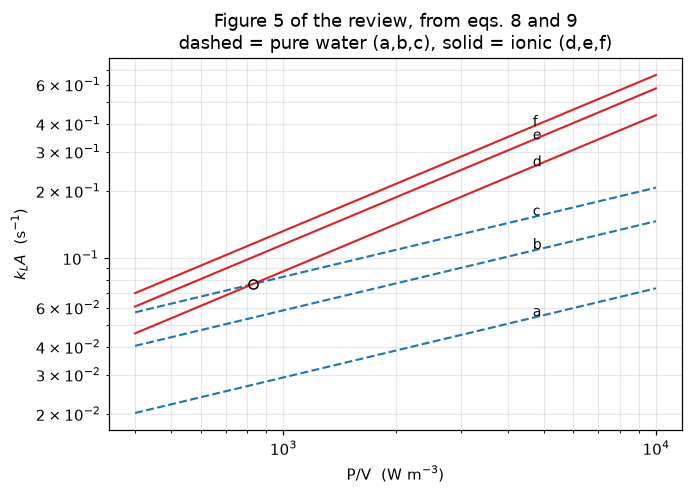

 pair     vs_pure    vs_ionic    PV_cross  in_window
a x d      0.0050      0.0050     25.8294      False
a x e      0.0050      0.0200     10.2504      False
a x f      0.0050      0.0400      6.4574      False
b x d      0.0200      0.0050    260.3442      False
b x e      0.0200      0.0200    103.3176      False
b x f      0.0200      0.0400     65.0860      False
c x d      0.0400      0.0050    826.5412       True
c x e      0.0400      0.0200    328.0131      False
c x f      0.0400      0.0400    206.6353      False

crossings inside the plotted window 4e2..1e4 : 1
the one that is inside                       : c x d at P/V = 826.5 W/m3

window left edge 400 W/m3 = Figure 5's printed axis label 4.10^2 (transcribed text, not a measured coordinate)
the count is 1 for any left edge in (328.0, 826.5] W/m3; at the printed validity bound 500 it is 1; at 300 it would be 2


In [6]:
PV = np.geomspace(400.0, 1e4, 400)
LAB = {("pure_water", 0.005): "a", ("pure_water", 0.020): "b", ("pure_water", 0.040): "c",
       ("ionic", 0.005): "d", ("ionic", 0.020): "e", ("ionic", 0.040): "f"}

fig, ax = plt.subplots(figsize=(6.4, 4.6))
for (br, vs), lab in LAB.items():
    ax.loglog(PV, kla(PV, vs, br), "--" if br == "pure_water" else "-",
              color="C0" if br == "pure_water" else "C3", lw=1.4)
    ax.annotate(lab, (PV[300], kla(PV[300], vs, br)), textcoords="offset points",
                xytext=(4, 2), fontsize=9)
rows = []
for lp, vp in zip("abc", VS_FIG5):
    for li, vi in zip("def", VS_FIG5):
        x = crossing_pv(vp, vi)
        rows.append((f"{lp} x {li}", vp, vi, x, 400.0 <= x <= 1e4))
cross = pd.DataFrame(rows, columns=["pair", "vs_pure", "vs_ionic", "PV_cross", "in_window"])
inside = cross[cross.in_window]
for _, r in inside.iterrows():
    ax.plot(r.PV_cross, kla(r.PV_cross, r.vs_pure, "pure_water"), "ko", ms=6, mfc="none")
ax.set_xlabel("P/V  (W m$^{-3}$)"); ax.set_ylabel("$k_L A$  (s$^{-1}$)")
ax.set_title("Figure 5 of the review, from eqs. 8 and 9\n"
             "dashed = pure water (a,b,c), solid = ionic (d,e,f)")
ax.grid(True, which="both", alpha=.3); plt.tight_layout(); plt.show()

print(cross.to_string(index=False, float_format=lambda v: f"{v:11.4f}"))
print(f"\ncrossings inside the plotted window 4e2..1e4 : {int(cross.in_window.sum())}")
print(f"the one that is inside                       : "
      f"{inside.pair.iloc[0]} at P/V = {inside.PV_cross.iloc[0]:.1f} W/m3")

# provenance of the window itself: its edges are Figure 5's printed axis
# labels, `4.10^2` and `10^4` on the abscissa (`2.10^-2` and `10^0` on the
# ordinate) - transcribed axis TEXT, not a measured coordinate. The left
# edge is load-bearing, so its sensitivity is printed rather than implied:
xs = np.sort(cross.PV_cross.values)
nxt = xs[xs < inside.PV_cross.iloc[0]].max()
n_at = lambda L: int(((xs >= L) & (xs <= 1e4)).sum())
print(f"\nwindow left edge 400 W/m3 = Figure 5's printed axis label 4.10^2 "
      f"(transcribed text, not a measured coordinate)")
print(f"the count is 1 for any left edge in ({nxt:.1f}, {inside.PV_cross.iloc[0]:.1f}] W/m3; "
      f"at the printed validity bound 500 it is {n_at(500.)}; at 300 it would be {n_at(300.)}")


**Exactly 1 of the nine candidate crossings falls inside the
plotted window**, at $P/V$ = 826.5 W m⁻³: the pure-water curve at
4 cm s⁻¹ (`c`) meeting the ionic curve at 0.5 cm s⁻¹ (`d`), a little to the left
of the 10³ gridline. The review's printed Figure 5 shows exactly one crossing,
between exactly that pair, in exactly that position.

That is a real check on the transcription of **both** branches at once, and it
is a sharp one: it reads all six constants. It is stated qualitatively on
purpose — the abscissa of the printed crossing is **not measured**, because
measuring it would be figure digitisation and this page does none. What is
compared is the *count* and the *identity of the pair*, both of which are
legible without extracting a coordinate.

**Where the window comes from, and how much hangs on it.** The window's edges
are Figure 5's printed axis *labels* — `4.10²` and `10⁴` on the abscissa —
which is transcription of typeset text, not a measured coordinate; it is
declared here because the left edge is load-bearing. The count is 1 only for a
left edge in (328.0, 826.5] W m⁻³ — at 300 W m⁻³ it
would be 2 — and the cell above prints that
sensitivity. It does not depend on which of the two defensible bounds is
chosen: at the printed *validity* bound, 500 W m⁻³, the count is still
1.

### 2. Which of the six constants the data actually exercise

The review poses this question about itself and does not answer it:

> *"Relatively much store is set by the values of $\alpha$ and $\beta$. To what
> extent these can be varied without affecting the outcome significantly will be
> discussed in more detail in the section on $k_\mathrm{L}A$."*

It never is. The answer is computable from printed numbers alone, and the
method matters: **changing an exponent alone is not the comparison to make**,
because a reader who preferred a different exponent would re-fit the prefactor
with it. The review says as much — *"it correlates a great deal with $\alpha$
because $P/V = 10^3\!-\!10^4$"*. So re-fit $K$ so the altered correlation is
exact at the geometric centre of the printed window, and ask how far it can then
stray anywhere inside that window. Compare against the review's own claimed
accuracy, 20–40 %.

In [7]:
VS_PURE = (0.0044, 0.040)   # span of the Figures 1-3 legends
VS_ION  = (0.0045, 0.047)   # span of the Figure 4 correlation lines C1, C2
ACC = (0.20, 0.40)

rows = []
def add(branch, sym, alt, ref, lo, hi, what):
    cost, fac = refit_cost(alt, ref, lo, hi, what)
    rows.append(dict(branch=branch, exponent=sym, printed=ref, alternative=alt,
                     lo_end=fac[0], hi_end=fac[1], worst_dev=cost,
                     inside_20_40=cost <= ACC[1]))

for a in (0.35, 0.5, 0.0):
    add("pure_water", "alpha", a, 0.4, 500., 1e4, "pv")
for b in (0.3, 0.6, 0.0):
    add("pure_water", "beta", b, 0.5, *VS_PURE, "vs")
for a in (0.4, 1.0, 0.0):
    add("ionic", "alpha", a, 0.7, 500., 1e4, "pv")
for b in (0.0, 0.7):
    add("ionic", "beta", b, 0.2, *VS_ION, "vs")
tol = pd.DataFrame(rows)
print(tol.to_string(index=False, float_format=lambda v: f"{v:8.4f}"))

print("\nNULL BASELINE - what each term buys over dropping it entirely")
print("  (prefactor re-fitted at the window centre in every case)")
for br, sym, ref, lo, hi, what in [("pure_water", "alpha", 0.4, 500., 1e4, "pv"),
                                   ("pure_water", "beta", 0.5, *VS_PURE, "vs"),
                                   ("ionic", "alpha", 0.7, 500., 1e4, "pv"),
                                   ("ionic", "beta", 0.2, *VS_ION, "vs")]:
    c, _ = refit_cost(0.0, ref, lo, hi, what)
    verdict = "INSIDE the review's own 20-40% band" if c <= ACC[1] else "outside it"
    print(f"  {br:11s} {sym:5s} = {ref:4.1f} -> 0 : worst {100*c:6.1f} %   {verdict}")

# VS_ION is the span of Figure 4's two DRAWN LINES (C1, C2). The figure's
# DATA occupy a wider span - Hassan 1977 at 0.0023 to Reith 1968 at 0.047,
# straight from the legend rows - so the ionic-beta null cost is printed
# over both spans rather than quietly over the narrower one.
f4 = legs[(legs.figure == 4) & (legs.method != "drawn correlation line")]
VS_ION_DATA = (float(f4.vs_m_s.min()), float(f4.vs_m_s.max()))
assert VS_ION_DATA == (0.0023, 0.047), VS_ION_DATA
c_lines, _ = refit_cost(0.0, 0.2, *VS_ION, "vs")
c_data, _ = refit_cost(0.0, 0.2, *VS_ION_DATA, "vs")
print(f"\nionic beta -> 0 over TWO spans: {100*c_lines:.1f} % over the drawn lines "
      f"C1..C2 ({VS_ION[0]}-{VS_ION[1]} m/s); {100*c_data:.1f} % over the DATA span "
      f"({VS_ION_DATA[0]}-{VS_ION_DATA[1]} m/s). Both inside 20-40 %.")

print("\nNULL BASELINE - dropping the BRANCHING and using eq. 8 for ionic systems")
pv2 = np.geomspace(500., 1e4, 400)[:, None]; vs2 = np.geomspace(*[VS_FIG5[0], VS_FIG5[-1]], 400)[None, :]
ratio = kla(pv2, vs2, "ionic") / kla(pv2, vs2, "pure_water")
print(f"  worst under-prediction {100*(1 - 1/ratio.max()):.1f} % "
      f"(ratio up to {ratio.max():.2f}x)")


    branch exponent  printed  alternative   lo_end   hi_end  worst_dev  inside_20_40
pure_water    alpha   0.4000       0.3500   1.0778   0.9278     0.0778          True
pure_water    alpha   0.4000       0.5000   0.8609   1.1616     0.1616          True
pure_water    alpha   0.4000       0.0000   1.8206   0.5493     0.8206         False
pure_water     beta   0.5000       0.3000   1.2470   0.8019     0.2470          True
pure_water     beta   0.5000       0.6000   0.8955   1.1167     0.1167          True
pure_water     beta   0.5000       0.0000   1.7364   0.5759     0.7364         False
     ionic    alpha   0.7000       0.4000   1.5673   0.6380     0.5673         False
     ionic    alpha   0.7000       1.0000   0.6380   1.5673     0.5673         False
     ionic    alpha   0.7000       0.0000   2.8534   0.3505     1.8534         False
     ionic     beta   0.2000       0.0000   1.2644   0.7909     0.2644          True
     ionic     beta   0.2000       0.7000   0.5563   1.7977     0

**The four exponents are not equally earned.**

Three of them are load-bearing. Dropping the $P/V$ term costs
82.1 % on the pure-water branch and
185.3 % on the ionic one; dropping the pure-water
$v_\mathrm{s}$ term costs 73.6 %. All three are well
outside the 20–40 % the review claims for its own formulas, so the data must be
resolving them.

**The fourth is not.** Deleting the ionic $v_\mathrm{s}$ term outright —
setting $\beta = 0$ and re-fitting the prefactor — changes the prediction by at
most **26.4 %** across the span of Figure 4's two drawn
correlation lines (0.0045–0.047 m s⁻¹), and by at most
**35.2 %** across the wider span the figure's
*data* occupy (0.0023–0.047 m s⁻¹, Hassan to Reith). Both are *inside* the
review's own stated accuracy — the second at the top of it. The exponent 0.2 on
the ionic branch is not resolved by the review's own error bar.

That is not a criticism the review would resist; it is what the review itself
reports its sources as finding, and this page only puts the number on it:

> *"Westerterp et al. (1963) and also Reith and Beek (1968) claim that at
> $v_\mathrm{s} > 0.5$ the superficial gas velocity exerts only a slight
> influence. Zlokarnik (1970) has found a slightly better correlation with
> $v_\mathrm{s}^{0.2}$ than with $v_\mathrm{s}^{0}$."*

The 0.2 was **imported from Zlokarnik, not fitted on Figure 4** — the review
says so in the sentence that introduces eq. 9 — and then $K$ and $\alpha$ were
fitted with it held. So it is not surprising that it sits inside the noise; what
is worth having is how far inside.

Within the *pure-water* literature spread the review quotes, $\alpha$ = 0.35–0.5
and $\beta$ = 0.3–0.6, the whole range costs at most
16.2 % and 24.7 %
respectively once $K$ is re-fitted — both at or inside the accuracy band. **The
spread in the literature exponents is not a disagreement about physics; it is
what a 20–40 % correlation looks like.**

### 3. The branching, against the review's own expectation for it

The review expects ions to raise $k_\mathrm{L}A$ by **2–10 times**, and it
builds that expectation *mechanistically* — interfacial area up to 10× (Lee &
Meyrick), holdup up to 2× (Machón et al.), $k_\mathrm{L}$ lower by at most 1–4× —
then corroborates it against Zlokarnik (1975). **None of that comes from eqs. 8
and 9.** So the ratio of the two fitted correlations is a genuine check against
an independently-argued number, and it can fail.

$$\frac{\text{eq. 9}}{\text{eq. 8}}
 = \frac{2.0\times10^{-3}}{2.6\times10^{-2}}
   \left(\frac{P/V}{v_\mathrm{s}}\right)^{0.3}$$

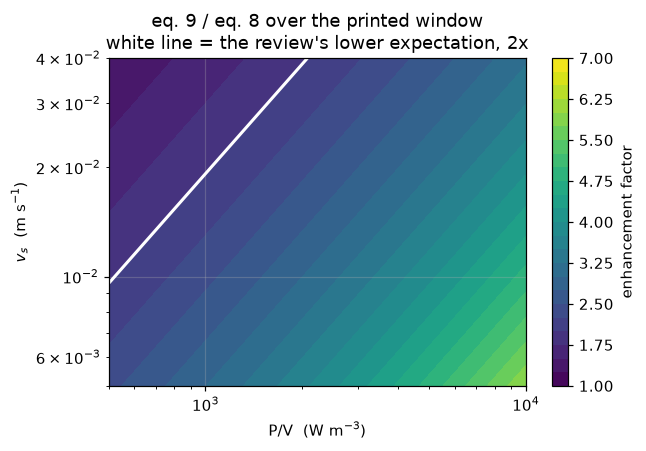

ratio spans 1.3036 to 5.9754 over the printed box
the review expects 2-10x; the two correlations deliver that on 83.6 % of the box
the shortfall corner: P/V = 500 W/m3, v_s = 0.0400 m/s -> ratio 1.30
using eq. 8 for an ionic system therefore under-predicts by up to 83.3 %

the review's two qualitative claims about the branching, as signs:
  'increases at higher P/V values'        : d lnR/d ln(P/V) = +0.3  -> holds
  'more dependent on P/V than pure water' : alpha 0.7 vs 0.4  -> holds
  (and the enhancement FALLS with v_s     : d lnR/d ln(v_s) = -0.3, which the review does not state)


In [8]:
# PV_GRID and VS_GRID come from the CORE cell: one grid for every map and
# every reported number on this page.
assert np.isclose(VS_GRID[0], VS_FIG5[0]) and np.isclose(VS_GRID[-1], VS_FIG5[-1]), \
    "VS_GRID must span the v_s values Figure 5's legend prints"
pvg, vsg = PV_GRID[:, None], VS_GRID[None, :]
R = kla(pvg, vsg, "ionic") / kla(pvg, vsg, "pure_water")
lo, hi = float(nums.loc["ion_enhancement_lo", "value"]), float(nums.loc["ion_enhancement_hi", "value"])

fig, ax = plt.subplots(figsize=(6.0, 4.2))
cs = ax.contourf(PV_GRID, VS_GRID, R.T, levels=np.linspace(1, 7, 25), cmap="viridis")
ax.contour(PV_GRID, VS_GRID, R.T, levels=[lo], colors="w", linewidths=2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("P/V  (W m$^{-3}$)"); ax.set_ylabel("$v_s$  (m s$^{-1}$)")
ax.set_title(f"eq. 9 / eq. 8 over the printed window\nwhite line = the review's lower "
             f"expectation, {lo:g}x")
plt.colorbar(cs, ax=ax, label="enhancement factor"); plt.tight_layout(); plt.show()

frac = float(np.mean((R >= lo) & (R <= hi)))
i, j = np.unravel_index(R.argmin(), R.shape)
print(f"ratio spans {R.min():.4f} to {R.max():.4f} over the printed box")
print(f"the review expects {lo:g}-{hi:g}x; the two correlations deliver that on "
      f"{100*frac:.1f} % of the box")
print(f"the shortfall corner: P/V = {PV_GRID[i]:.0f} W/m3, v_s = {VS_GRID[j]:.4f} m/s "
      f"-> ratio {R.min():.2f}")
print(f"using eq. 8 for an ionic system therefore under-predicts by up to "
      f"{100*(1 - 1/R.max()):.1f} %")
print()
print("the review's two qualitative claims about the branching, as signs:")
da = CORR['ionic']['alpha'] - CORR['pure_water']['alpha']
db = CORR['ionic']['beta'] - CORR['pure_water']['beta']
print(f"  'increases at higher P/V values'        : d lnR/d ln(P/V) = {da:+.1f}"
      f"  -> {'holds' if da > 0 else 'FAILS'}")
print(f"  'more dependent on P/V than pure water' : alpha {CORR['ionic']['alpha']} vs "
      f"{CORR['pure_water']['alpha']}  -> {'holds' if da > 0 else 'FAILS'}")
print(f"  (and the enhancement FALLS with v_s     : d lnR/d ln(v_s) = {db:+.1f}, "
      f"which the review does not state)")


Over the box the two correlations deliver an enhancement of
**1.30× to 5.98×**, and they land inside the review's
own expected 2–10× on 83.6 % of it. The review's qualitative
claims about the branching are recovered exactly — the enhancement *does* grow
with $P/V$, because $0.7 > 0.4$, which is the sentence *"the
$k_\mathrm{L}A$'s for ionic solutions are more dependent on $P/V$ than those
for pure water"*.

**But the corner at high $v_\mathrm{s}$ and low $P/V$ falls to
1.30×, below the 2× floor the review argues for.** The two things
are printed four pages apart, and neither is derived from the other, so this is
a genuine internal inconsistency rather than an arithmetic slip: at 4 cm s⁻¹ and
500 W m⁻³ the review's own fitted correlations say adding salt barely changes
$k_\mathrm{L}A$, while its own mechanistic argument says it must at least
double it. The page reports it and does not resolve it — the evidence that would
settle it is in Figures 3 and 4, which are not digitised.

The **branch null baseline** is the other half of this: using eq. 8 for an ionic
system under-predicts by up to 83.3 %. The branching
is the single most load-bearing feature of the correlation, which is exactly why
a page that checked only one branch would be worthless.

### 4. Where the correlation outgrows the method that produced it

The review states, precisely, how fast a $k_\mathrm{L}A$ a normal electrode can
follow: *"commercially available electrodes with $\tau_\mathrm{p}$ = 2 or 3 s to
$k_\mathrm{L}A = 0.1$ s⁻¹"*. That ceiling is not a free-standing number — it is
Linek's criterion $\tau_\mathrm{p} \le 1/(5k_\mathrm{L}A)$ evaluated at
$\tau_\mathrm{p}$ = 2 s, and recovering it is a check on three separate
transcriptions at once.

recovering the printed electrode ceiling from the printed probe criteria
  tau_p = 2 s :  Linek       (<3% err) k_LA <= 1/(5 tau_p) = 0.1000 1/s
              :  Van de Sande (<6% err) k_LA <= 1/tau_p        = 0.5000 1/s
  tau_p = 3 s :  Linek       (<3% err) k_LA <= 1/(5 tau_p) = 0.0667 1/s
              :  Van de Sande (<6% err) k_LA <= 1/tau_p        = 0.3333 1/s
  printed ceiling = 0.1 1/s; 1/(5 x 2 s) = 0.1000 1/s
  pure_water :  23.3 % of the printed window lies above k_LA = 0.1 1/s
  ionic      :  80.5 % of the printed window lies above k_LA = 0.1 1/s


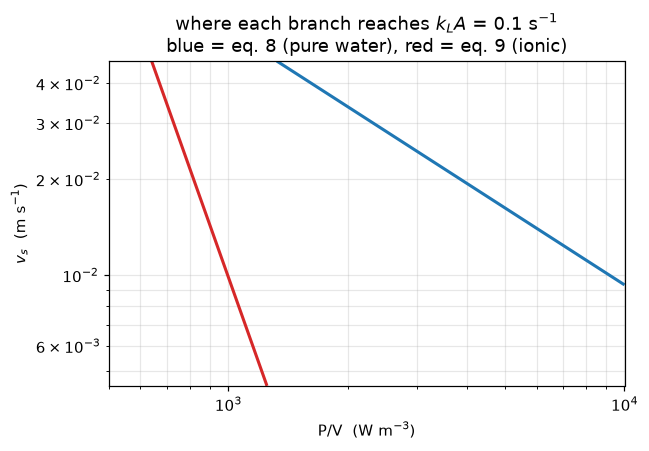

  v_s = 0.005 m/s : reached at P/V =    21820 (pure) and     1215 (ionic) W/m3
  v_s = 0.020 m/s : reached at P/V =     3857 (pure) and      818 (ionic) W/m3
  v_s = 0.040 m/s : reached at P/V =     1622 (pure) and      671 (ionic) W/m3

  the ionic branch is above the ceiling everywhere past P/V = 1215 W/m3, at every v_s Figure 5 draws


In [9]:
tau_lo = float(nums.loc["probe_tau_lo", "value"])
tau_hi = float(nums.loc["probe_tau_hi", "value"])
marg   = float(nums.loc["linek_margin", "value"])
ceil   = float(nums.loc["kla_electrode_ceiling", "value"])
print("recovering the printed electrode ceiling from the printed probe criteria")
for t in (tau_lo, tau_hi):
    print(f"  tau_p = {t:.0f} s :  Linek       (<3% err) k_LA <= 1/(5 tau_p) = {1/(marg*t):.4f} 1/s")
    print(f"              :  Van de Sande (<6% err) k_LA <= 1/tau_p        = {1/t:.4f} 1/s")
print(f"  printed ceiling = {ceil} 1/s; 1/(5 x {tau_lo:.0f} s) = {1/(marg*tau_lo):.4f} 1/s")

# where each branch crosses that ceiling. VS_GRID_WIDE is Figure 4's C1..C2 span.
pvw, vsw = PV_GRID[:, None], VS_GRID_WIDE[None, :]
frac_above = {}
fig, ax = plt.subplots(figsize=(6.0, 4.2))
for br, col in [("pure_water", "C0"), ("ionic", "C3")]:
    K = kla(pvw, vsw, br)
    frac_above[br] = float(np.mean(K > ceil))
    ax.contour(PV_GRID, VS_GRID_WIDE, K.T, levels=[ceil], colors=col, linewidths=2)
    print(f"  {br:11s}: {100*frac_above[br]:5.1f} % of the printed window lies above "
          f"k_LA = {ceil} 1/s")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("P/V  (W m$^{-3}$)"); ax.set_ylabel("$v_s$  (m s$^{-1}$)")
ax.set_title(f"where each branch reaches $k_LA$ = {ceil} s$^{{-1}}$\n"
             "blue = eq. 8 (pure water), red = eq. 9 (ionic)")
ax.grid(True, which="both", alpha=.3); plt.tight_layout(); plt.show()
pv_ceiling_ion = 0.0
for v in VS_FIG5:
    p8 = (ceil / (CORR["pure_water"]["K"] * v**CORR["pure_water"]["beta"]))**(1/CORR["pure_water"]["alpha"])
    p9 = (ceil / (CORR["ionic"]["K"] * v**CORR["ionic"]["beta"]))**(1/CORR["ionic"]["alpha"])
    pv_ceiling_ion = max(pv_ceiling_ion, p9)
    print(f"  v_s = {v:.3f} m/s : reached at P/V = {p8:8.0f} (pure) and {p9:8.0f} (ionic) W/m3")
print(f"\n  the ionic branch is above the ceiling everywhere past P/V = "
      f"{pv_ceiling_ion:.0f} W/m3, at every v_s Figure 5 draws")


$1/(5\times 2\,\mathrm{s}) = 0.1$ s⁻¹ — the review's
printed ceiling is **exactly** Linek's tighter criterion at the faster of the two
electrodes it names. Three numbers read off a scan, and they close.

Applied to the correlations, the two branches behave completely differently.
Eq. 8 stays below the ceiling over most of the printed window
(23.3 % of it lies above), while **eq. 9 is above it over
80.5 %** — the ionic branch has crossed $k_\mathrm{L}A$ = 0.1 s⁻¹
by $P/V$ = 1215 W m⁻³ at every velocity Figure 5 draws. So most of the
ionic correlation's own validity window lies in the regime where the review says
a response model is required. That is not a contradiction — the review says
plainly that with response models *"one can measure up to values several times
higher"* — but it does say that the ionic branch is, over most of its range, a
correlation of *corrected* measurements rather than raw ones, and the review's
own warning about how much accuracy those corrections cost applies to it far
more than to eq. 8.

### 5. What the well-mixed-gas assumption costs — the pymrm part

Everything above is arithmetic on printed constants. This is the part that needs
a model.

Eq. 2 assumes the gas composition is uniform and equal to the inlet. The review
returns to that four times, gives the residence time that governs it (eq. 3),
says the problem worsens with vessel size and at low $v_\mathrm{s}$ — and stops. With the plug-flow column solved, the cost becomes a number:
$\varphi$, the ratio of the true column-mean driving force to the one eq. 2
assumes. **The $k_\mathrm{L}A$ an experimenter reports is $\varphi$ times the
real one.**

In [10]:
V_WORK, TH = 2.6, 1.0            # m3 (eq. 8's printed max, inside eq. 9's window); T/H centre
H_T = (4*V_WORK/(np.pi*TH**2))**(1/3)   # V = pi T^2 H_t/4 with T = TH*H_t
EPS, HENRY = 0.10, 30.0          # NOT printed in the review - see Parameters
PV_WORK = float(np.sqrt(500.*1e4))
print(f"worked vessel: V = {V_WORK*1e3:.0f} L, T/H = {TH}, so H_t = {H_T:.4f} m and "
      f"T = {TH*H_T:.4f} m (from the review's own eq. 3 geometry)")
print(f"worked point : P/V = {PV_WORK:.1f} W/m3 (geometric centre of the printed window)\n")

rows = []
for br in ("pure_water", "ionic"):
    for vs in VS_FIG5:
        k = float(kla(PV_WORK, vs, br))
        NG = float(stripping_number(k, H_T, vs, EPS, HENRY))
        rows.append(dict(branch=br, vs=vs, kLA=k, tau_G=EPS*H_T/vs,
                         tauG_times_kLA=EPS*H_T/vs*k, N_G=NG,
                         phi=float(phi_closed(NG)), bias_pct=100*(1-float(phi_closed(NG)))))
dep = pd.DataFrame(rows)
print(dep.to_string(index=False, float_format=lambda v: f"{v:9.4f}"))
print("\n`tauG_times_kLA` is the review's OWN criterion; `N_G` is the one the balance gives.")
print(f"they differ by the factor (1-eps)/(eps H) = {(1-EPS)/(EPS*HENRY):.4f}, "
      f"which the review's criterion omits.")


worked vessel: V = 2600 L, T/H = 1.0, so H_t = 1.4904 m and T = 1.4904 m (from the review's own eq. 3 geometry)
worked point : P/V = 2236.1 W/m3 (geometric centre of the printed window)

    branch        vs       kLA     tau_G  tauG_times_kLA       N_G       phi  bias_pct
pure_water    0.0050    0.0402   29.8074          1.1983    0.3595    0.8400   16.0014
pure_water    0.0200    0.0804    7.4519          0.5992    0.1797    0.9153    8.4723
pure_water    0.0400    0.1137    3.7259          0.4237    0.1271    0.9391    6.0942
     ionic    0.0050    0.1533   29.8074          4.5687    1.3706    0.5443   45.5679
     ionic    0.0200    0.2022    7.4519          1.5071    0.4521    0.8045   19.5521
     ionic    0.0400    0.2323    3.7259          0.8656    0.2597    0.8807   11.9294

`tauG_times_kLA` is the review's OWN criterion; `N_G` is the one the balance gives.
they differ by the factor (1-eps)/(eps H) = 0.3000, which the review's criterion omits.


at P/V = 2236 W/m3 and v_s = 0.005 m/s, over the printed vessel volumes:

      V_L       H_t  phi_pure_water  bias_pure_water_pct  phi_ionic  bias_ionic_pct
   2.5000    0.1471          0.9825               1.7534     0.9353          6.4690
   5.0000    0.1853          0.9780               2.2023     0.9194          8.0578
  21.0000    0.2990          0.9648               3.5213     0.8743         12.5715
  40.0000    0.3707          0.9566               4.3403     0.8474         15.2618
  70.0000    0.4467          0.9480               5.1990     0.8201         17.9936
  90.0000    0.4857          0.9436               5.6359     0.8065         19.3492
 180.0000    0.6120          0.9297               7.0306     0.7647         23.5268
1360.0000    1.2008          0.8682              13.1802     0.6054         39.4594
4400.0000    1.7760          0.8134              18.6630     0.4927         50.7309
5100.0000    1.8656          0.8053              19.4736     0.4780         52.1967


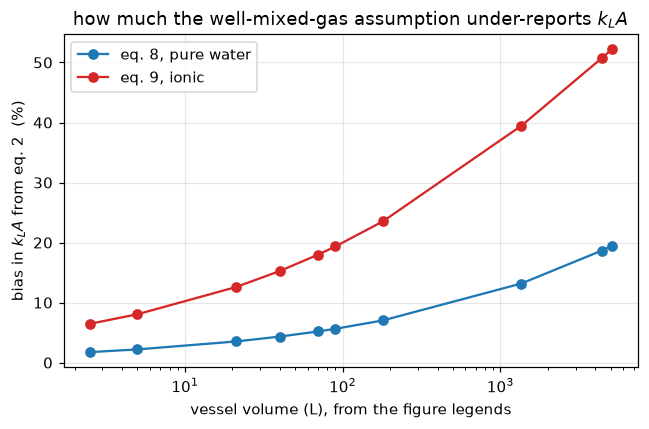

In [11]:
# the vessel-size dependence the review asserts and never quantifies,
# run over the vessel volumes its own figure legends print
vs0 = VS_FIG5[0]
rows = []
for V in V_PRINTED:
    h = (4*V*1e-3/np.pi)**(1/3)
    r = dict(V_L=V, H_t=h)
    for br in ("pure_water", "ionic"):
        k = float(kla(PV_WORK, vs0, br))
        r[f"phi_{br}"] = float(phi_closed(stripping_number(k, h, vs0, EPS, HENRY)))
        r[f"bias_{br}_pct"] = 100*(1 - r[f"phi_{br}"])
    rows.append(r)
size = pd.DataFrame(rows)
print(f"at P/V = {PV_WORK:.0f} W/m3 and v_s = {vs0} m/s, over the printed vessel volumes:\n")
print(size.to_string(index=False, float_format=lambda v: f"{v:9.4f}"))

fig, ax = plt.subplots(figsize=(6.0, 4.0))
for br, col, lab in [("pure_water", "C0", "eq. 8, pure water"), ("ionic", "C3", "eq. 9, ionic")]:
    ax.semilogx(size.V_L, size[f"bias_{br}_pct"], "o-", color=col, label=lab)
ax.set_xlabel("vessel volume (L), from the figure legends")
ax.set_ylabel("bias in $k_LA$ from eq. 2  (%)")
ax.set_title("how much the well-mixed-gas assumption under-reports $k_LA$")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()


At the geometric centre of the printed $P/V$ window
(2236 W m⁻³), at the lowest velocity Figure 5 draws
(0.5 cm s⁻¹), in a 2600 L vessel of height
1.49 m:

| branch | $k_\mathrm{L}A$ (s⁻¹) | $N_\mathrm{G}$ | $\varphi$ | eq. 2 under-reports by (quasi-steady) |
| --- | --- | --- | --- | --- |
| eq. 8, pure water | 0.0402 | 0.359 | 0.840 | **16.0 %** |
| eq. 9, ionic | 0.1533 | 1.371 | 0.544 | **45.6 %** |

**The $\varphi$'s above are quasi-steady, and the page's own transient says the
quasi-steady number is the optimistic one.** $\varphi = (1-e^{-N_G})/N_G$
freezes the gas column, which is valid when
$\tau_\mathrm{G} \ll 1/k_\mathrm{L}A$ — *exactly the condition being
shown to fail* ($\tau_\mathrm{G}$ = 29.8 s here, against
$1/(k\varphi)$ = 29.6 s pure and 12.0 s
ionic). Solving the full transient gassing-out experiment and applying eq. 2 to
the trace (Validation) gives an under-report of **19.1 %**
on the pure-water branch, not 16.0 %. On the ionic branch
the two timescales are farthest apart, the response is genuinely
non-exponential, and what eq. 2 returns therefore depends on where the trace is
fitted: 34.1–56.5 %
across the fit windows swept in Validation, 45.4 % at the
(0.2, 0.8) window, with the quasi-steady 45.6 % inside that
range. The transient numbers lead the headline; $\varphi$ is kept beside them
because it is closed-form, deterministic and free of any window choice.

**The branch matters more here than anywhere else on the page.** The bias is
45.6 % on the ionic branch against 16.0 %
on the pure-water one, and the whole of that difference comes from the four
constants: eq. 9 predicts 3.8× the transfer coefficient
at this point, hence 3.8× the stripping number in the
same gas stream. **45.6 % is the same size as the entire
accuracy the review claims for its formulas.**

And across the vessel sizes the review's own legends print, the effect runs from
6.5 % in a 2.5 L bench vessel to
52.2 % in Calderbank's 5100 L one — which is precisely
the review's sentence *"Problems become more serious at larger vessel diameter
especially at low superficial gas velocity values"*, with numbers on it for the
first time. The direction, the vessel-size trend and the $v_\mathrm{s}$ trend
are all the review's own claims; what is new is the magnitude, and the fact that
it is **branch-dependent**.

Three honest qualifications, all load-bearing.

**This is a statement about the correlation's self-consistency, not a
correction to it.** If the underlying measurements were biased low by
$\varphi$, then eq. 9 as fitted already contains that bias, and dividing by
$\varphi$ would double-count. What the calculation establishes is that eq. 9,
taken at face value, predicts conditions under which the method that produced
most of its data does not measure what it is assumed to measure.

**$H$ is not printed in the review.** $N_\mathrm{G}$ is inversely
proportional to it, so the numbers above move with it; Validation sweeps
$H$ = 20–40 and reports the range, and the $H$-free group $N_\mathrm{G}H$ is
reported beside them.

**$V$ does double duty as liquid volume and dispersion volume.** The review's
Nomenclature defines $V$ as the *fluid* volume; this page sets
$H_\mathrm{t}$ from $V = \tfrac14\pi T^2 H_\mathrm{t}$ at $V$ = 2.6 m³
and then uses that $H_\mathrm{t}$ as the *dispersion* height in
$N_\mathrm{G}$. At $\epsilon$ = 0.1 with the aspect ratio held, the
dispersion height is larger by $(1-\epsilon)^{-1/3}$, i.e.
+3.6 % on $N_\mathrm{G}$ — inside the
$\epsilon$-sweep envelope, and the same identification the review's own eq. 3
makes.

## Validation

**This page is a REPRODUCTION, NOT A VALIDATION, and the distinction is not
cosmetic here.** Eqs. 8 and 9 were *fitted* by van 't Riet to the literature
data he compiles in Figures 1–5. Any agreement between them and those data would
be a goodness of fit, not a test — and this page cannot even compute that,
because the data live only in the figures and figure extraction needs a
maintainer review that is not available. The data tier is 6. **No measurement is
compared against anywhere on this page.**

What can be checked, and is:

1. the pymrm column against a closed form derived independently of it;
2. the pymrm transient against a Lagrangian route that forms no spatial
   operator — with the route's claimed sensitivities *measured*, not asserted;
3. a global oxygen balance across the two phases;
4. the review's internal identities — eq. 3's two forms, and the electrode
   ceiling recovered from the two probe criteria;
5. a deliberate-break table whose eight metrics are recomputed under every
   break — and an explicit accounting of which reported metrics live outside
   it.

In [12]:
print("=== 1. pymrm column vs the closed form, and the grid order ===")
vs0 = VS_FIG5[0]
grid_rows = []
for br in ("pure_water", "ionic"):
    k = float(kla(PV_WORK, vs0, br))
    NG = float(stripping_number(k, H_T, vs0, EPS, HENRY)); exact = float(phi_closed(NG))
    errs = {}
    for n in (100, 200, 400, 800, 1600):
        errs[n] = abs(phi_pymrm(n, H_T, vs0, EPS, k, HENRY) - exact)
    order = [np.log2(errs[n]/errs[2*n]) for n in (100, 200, 400, 800)]
    v800 = phi_pymrm(800, H_T, vs0, EPS, k, HENRY)
    v1600 = phi_pymrm(1600, H_T, vs0, EPS, k, HENRY)
    rich = v1600 + (v1600 - v800)
    grid_rows.append(dict(branch=br, phi_exact=exact, phi_n1600=v1600,
                          rel_err_n1600=abs(v1600/exact-1),
                          richardson=rich, rel_err_richardson=abs(rich/exact-1),
                          observed_order=float(np.mean(order))))
    print(f"  {br:11s} errors {[f'{errs[n]:.3e}' for n in errs]}")
    print(f"  {'':11s} order  {[f'{o:.3f}' for o in order]}   (upwind convection: 1)")
gridres = pd.DataFrame(grid_rows)
print()
print(gridres.to_string(index=False, float_format=lambda v: f"{v:12.6e}"))


=== 1. pymrm column vs the closed form, and the grid order ===


  pure_water  errors ['1.249e-03', '6.260e-04', '3.133e-04', '1.568e-04', '7.840e-05']
              order  ['0.997', '0.998', '0.999', '1.000']   (upwind convection: 1)
  ionic       errors ['1.729e-03', '8.673e-04', '4.344e-04', '2.174e-04', '1.087e-04']
              order  ['0.995', '0.998', '0.999', '0.999']   (upwind convection: 1)

    branch    phi_exact    phi_n1600  rel_err_n1600   richardson  rel_err_richardson  observed_order
pure_water 8.399857e-01 8.399073e-01   9.333211e-05 8.399856e-01        5.010681e-08    9.985480e-01
     ionic 5.443213e-01 5.442126e-01   1.997474e-04 5.443212e-01        1.663029e-07    9.977494e-01


In [13]:
print("=== 2. the transient, and the INDEPENDENT Lagrangian route ===")
tr, wsw = [], []
for br in ("pure_water", "ionic"):
    k = float(kla(PV_WORK, vs0, br))
    NG = float(stripping_number(k, H_T, vs0, EPS, HENRY)); phi = float(phi_closed(NG))
    t_end = 6.0/(k*phi); C_star = 8.5/HENRY
    # dt refinement: UNIFORM steps, refined uniformly. A geometric schedule
    # would make dt0 the wrong knob to refine - docs/agent-brief.md, A4.7.
    r = {}
    for nt in (1000, 2000, 4000):
        ts, CLs, _, _ = gassing_out(800, nt, t_end, H_T, vs0, EPS, k, HENRY)
        r[nt] = fit_eq2(ts, CLs, C_star)/k
    ords = np.log2((r[1000]-r[2000])/(r[2000]-r[4000]))
    rich = 2*r[4000] - r[2000]                 # first order in dt -> Richardson
    for nt in (1000, 2000, 4000):
        print(f"  {br:11s} nt={nt:5d}: k_app/k = {r[nt]:.6f}")
    print(f"  {'':11s} observed temporal order {ords:.3f}; Richardson -> {rich:.6f}")

    ts, CLs, Cg, bal = gassing_out(800, 4000, t_end, H_T, vs0, EPS, k, HENRY)
    tl, CLl = lagrangian(400, 4000, t_end, H_T, vs0, EPS, k, HENRY)
    ti, CLi, _, _ = gassing_out(800, 4000, t_end, H_T, vs0, EPS, k, HENRY,
                                gas_initially_inert=True)
    b, c = fit_eq2(tl, CLl, C_star)/k, fit_eq2(ti, CLi, C_star)/k
    tr.append(dict(branch=br, phi_quasisteady=phi, kapp_over_k=r[4000],
                   kapp_richardson=rich, lagrangian=b, rel_gap=abs(b/rich-1),
                   gas_initially_inert=c, o2_balance_resid=bal))
    print(f"  {'':11s} phi(quasi-steady) = {phi:.6f}   (gas inventory neglected)")
    print(f"  {'':11s} Lagrangian route  = {b:.6f}   (rel gap to Richardson {abs(b/rich-1):.2e})")
    print(f"  {'':11s} gas inert at t=0  = {c:.6f}   (N2 still in the vessel at the switch)")
    print(f"  {'':11s} O2 balance resid  = {bal:.2e}   (operator's own face fluxes)")
    # eq. 2's fit window (f1, f2) is a CHOICE - the review prescribes none -
    # so its effect is printed instead of hidden inside a default:
    for f1, f2 in ((0.1, 0.9), (0.2, 0.8), (0.3, 0.7)):
        wa = fit_eq2(ts, CLs, C_star, f1, f2)/k
        wi = fit_eq2(ti, CLi, C_star, f1, f2)/k
        wsw.append(dict(branch=br, f1=f1, f2=f2, kapp_over_k=wa, inert_start=wi))
        print(f"  {'':11s} fit window ({f1:.1f}, {f2:.1f}): k_app/k = {wa:.4f}"
              f"   inert start = {wi:.4f}")
trans = pd.DataFrame(tr); wsw = pd.DataFrame(wsw)
tau_G = EPS*H_T/vs0
p_i = float(trans.loc[trans.branch == "ionic", "phi_quasisteady"].iloc[0])
p_p = float(trans.loc[trans.branch == "pure_water", "phi_quasisteady"].iloc[0])
k_i = float(kla(PV_WORK, vs0, "ionic")); k_p = float(kla(PV_WORK, vs0, "pure_water"))
wi_ = wsw[wsw.branch == "ionic"]
print(f"\nTHE WINDOW MATTERS ON THE IONIC BRANCH, AND THE REASON IS PHYSICAL:")
print(f"  tau_G = {tau_G:.1f} s exceeds the ionic liquid time constant 1/(k*phi) = "
      f"{1/(k_i*p_i):.1f} s")
print(f"  (pure water: 1/(k*phi) = {1/(k_p*p_p):.1f} s, comparable to tau_G), so the ionic")
print(f"  response is two-timescale and NOT a single exponential - which is exactly why")
print(f"  eq. 2 misfires there. k_app/k spans {wi_.kapp_over_k.min():.4f} to "
      f"{wi_.kapp_over_k.max():.4f} over the three windows.")
print(f"  In particular: k_app/k at (0.2, 0.8) = "
      f"{float(wi_[(wi_.f1 == 0.2)].kapp_over_k.iloc[0]):.4f} landing within "
      f"{100*abs(float(wi_[(wi_.f1 == 0.2)].kapp_over_k.iloc[0])/p_i - 1):.1f} % of the")
print(f"  quasi-steady phi = {p_i:.4f} is WINDOW-DEPENDENT, not corroboration: the other")
print(f"  windows land ~20 % away on either side. That eq. 2's answer depends on where")
print(f"  the trace is fitted is itself the finding.")


=== 2. the transient, and the INDEPENDENT Lagrangian route ===


  pure_water  nt= 1000: k_app/k = 0.806672
  pure_water  nt= 2000: k_app/k = 0.807702
  pure_water  nt= 4000: k_app/k = 0.808220
              observed temporal order 0.992; Richardson -> 0.808738


              phi(quasi-steady) = 0.839986   (gas inventory neglected)
              Lagrangian route  = 0.808863   (rel gap to Richardson 1.55e-04)
              gas inert at t=0  = 0.754014   (N2 still in the vessel at the switch)
              O2 balance resid  = 1.40e-10   (operator's own face fluxes)
              fit window (0.1, 0.9): k_app/k = 0.8052   inert start = 0.7336
              fit window (0.2, 0.8): k_app/k = 0.8082   inert start = 0.7540
              fit window (0.3, 0.7): k_app/k = 0.8082   inert start = 0.7749


  ionic       nt= 1000: k_app/k = 0.544886
  ionic       nt= 2000: k_app/k = 0.545572
  ionic       nt= 4000: k_app/k = 0.545917
              observed temporal order 0.994; Richardson -> 0.546262


              phi(quasi-steady) = 0.544321   (gas inventory neglected)
              Lagrangian route  = 0.546328   (rel gap to Richardson 1.21e-04)
              gas inert at t=0  = 0.283653   (N2 still in the vessel at the switch)
              O2 balance resid  = 1.45e-10   (operator's own face fluxes)
              fit window (0.1, 0.9): k_app/k = 0.4346   inert start = 0.2799
              fit window (0.2, 0.8): k_app/k = 0.5459   inert start = 0.2837
              fit window (0.3, 0.7): k_app/k = 0.6586   inert start = 0.2908

THE WINDOW MATTERS ON THE IONIC BRANCH, AND THE REASON IS PHYSICAL:
  tau_G = 29.8 s exceeds the ionic liquid time constant 1/(k*phi) = 12.0 s
  (pure water: 1/(k*phi) = 29.6 s, comparable to tau_G), so the ionic
  response is two-timescale and NOT a single exponential - which is exactly why
  eq. 2 misfires there. k_app/k spans 0.4346 to 0.6586 over the three windows.
  In particular: k_app/k at (0.2, 0.8) = 0.5459 landing within 0.3 % of the
  quasi-stead

In [14]:
print("=== 3. a pymrm note the balance turned up ===")
# The global O2 balance above uses the OPERATOR'S face fluxes. Written by hand
# as v_s*C_N - the pure-upwind outlet flux - it does NOT close, because pymrm's
# Neumann outflow bc extrapolates to the face instead of taking the upwind
# cell. The gap is O(1/n) and converges away; it is recorded because a hand
# -written balance that misses by 1e-4 looks like a physics error and is not.
k = float(kla(PV_WORK, vs0, "ionic"))
for n in (8, 100, 800):
    L, g, Conv, cbc = _operators(n, H_T, vs0, C_in=8.5, return_flux=True)
    c = np.linspace(1.0, 2.0, n)
    f = np.asarray(Conv @ c.reshape(-1, 1)).ravel() + cbc
    print(f"  n={n:4d}: operator outlet flux {f[-1]:.8f}, hand-written v_s*C_N "
          f"{vs0*c[-1]:.8f}, gap {abs(f[-1]/(vs0*c[-1])-1):.3e}")
print("  inlet face flux is exactly v_s*C_in, as the Dirichlet bc requires.")


=== 3. a pymrm note the balance turned up ===
  n=   8: operator outlet flux 0.01008929, hand-written v_s*C_N 0.01000000, gap 8.929e-03
  n= 100: operator outlet flux 0.01000631, hand-written v_s*C_N 0.01000000, gap 6.313e-04
  n= 800: operator outlet flux 0.01000078, hand-written v_s*C_N 0.01000000, gap 7.822e-05
  inlet face flux is exactly v_s*C_in, as the Dirichlet bc requires.


In [15]:
print("=== 4. the review's own identities ===")
# eq. 3: tau_G = eps V / (v_s . pi T^2/4) = eps H_t / v_s, which HOLDS ONLY IF
# V = pi T^2 H_t / 4. Check both forms agree for the worked vessel.
T = TH * H_T
lhs = EPS*V_WORK/(vs0*0.25*np.pi*T**2); rhs = EPS*H_T/vs0
print(f"  eq. 3 two forms: {lhs:.9f} s and {rhs:.9f} s, rel gap {abs(lhs/rhs-1):.2e}")
print("    STRUCTURAL: an identity of the cylinder, not of the model. It confirms the")
print("    geometry convention (H_t is the DISPERSION height, V the dispersion volume)")
print("    and nothing else. It cannot fail for any k_LA, eps or v_s.")
ceil = float(nums.loc["kla_electrode_ceiling", "value"])
marg = float(nums.loc["linek_margin", "value"]); tp = float(nums.loc["probe_tau_lo", "value"])
print(f"  electrode ceiling: 1/({marg:.0f} x {tp:.0f} s) = {1/(marg*tp):.4f} 1/s "
      f"vs printed {ceil:.4f} 1/s")
print("    NOT structural: three independently transcribed numbers close on the fourth.")

print("\n=== the one un-printed input, swept ===")
for br in ("pure_water", "ionic"):
    k = float(kla(PV_WORK, vs0, br))
    NGH = (1-EPS)*k*H_T/vs0          # H-free
    out = []
    for Hv in (20., 30., 40.):
        out.append(f"H={Hv:.0f}: phi={float(phi_closed(NGH/Hv)):.4f}")
    print(f"  {br:11s} N_G*H = {NGH:.4f} (dimensionless, H-free)   " + "  ".join(out))
for e in (0.05, 0.10, 0.20):
    k = float(kla(PV_WORK, vs0, "ionic"))
    print(f"  ionic  eps={e:.2f}: phi = {float(phi_closed(stripping_number(k,H_T,vs0,e,HENRY))):.4f}")
for th in (0.5, 1.0, 1.5):           # printed window 0.5 < T/H < 1.5
    h = (4*V_WORK/(np.pi*th**2))**(1/3)   # V = pi T^2 H_t/4 with T = th*H_t
    k = float(kla(PV_WORK, vs0, "ionic"))
    V_impl = np.pi*(th*h)**2*h/4          # the identity that pins the geometry
    print(f"  ionic  T/H={th:.1f}: H_t = {h:.3f} m, T = {th*h:.3f} m, implied V = "
          f"{V_impl:.3f} m3, phi = "
          f"{float(phi_closed(stripping_number(k,h,vs0,EPS,HENRY))):.4f}")
print("    the trend SUPPORTS the review's warning that the well-mixed-gas assumption")
print("    'can be dangerous in vessels with a tank height ... ratio H_t/T >> 1': the")
print("    TALL vessel (T/H = 0.5, i.e. H_t/T = 2) loses the most driving force. The")
print("    implied-volume column is printed because an earlier version of this sweep")
print("    computed the tank DIAMETER where the height belongs - a defect whose implied")
print(f"    volume is V*th^3, i.e. vessels of {V_WORK*0.5**3:.3f} to {V_WORK*1.5**3:.3f} m3 "
      f"instead of {V_WORK} - and INVERTED")
print("    this trend - see the break table.")


=== 4. the review's own identities ===
  eq. 3 two forms: 29.807426692 s and 29.807426692 s, rel gap 2.22e-16
    STRUCTURAL: an identity of the cylinder, not of the model. It confirms the
    geometry convention (H_t is the DISPERSION height, V the dispersion volume)
    and nothing else. It cannot fail for any k_LA, eps or v_s.
  electrode ceiling: 1/(5 x 2 s) = 0.1000 1/s vs printed 0.1000 1/s
    NOT structural: three independently transcribed numbers close on the fourth.

=== the one un-printed input, swept ===
  pure_water  N_G*H = 10.7850 (dimensionless, H-free)   H=20: phi=0.7730  H=30: phi=0.8400  H=40: phi=0.8765
  ionic       N_G*H = 41.1179 (dimensionless, H-free)   H=20: phi=0.4242  H=30: phi=0.5443  H=40: phi=0.6248
  ionic  eps=0.05: phi = 0.5285
  ionic  eps=0.10: phi = 0.5443
  ionic  eps=0.20: phi = 0.5781
  ionic  T/H=0.5: H_t = 2.366 m, T = 1.183 m, implied V = 2.600 m3, phi = 0.4074
  ionic  T/H=1.0: H_t = 1.490 m, T = 1.490 m, implied V = 2.600 m3, phi = 0.5443
  

### The break table

The table recomputes its **eight** metrics under every injected defect, so for
those eight the off-diagonal is **measured** rather than assumed. The eight are
representative, not exhaustive: the grid-order and Richardson numbers, the
$k_\mathrm{app}/k$ family, the Lagrangian gaps, the $H$- and vessel-size sweeps
of $\varphi$, the null-baseline costs and the electrode-ceiling numbers are
reported *outside* the table, and the report cell below counts exactly how many
reported metrics the table covers. `A4.2` and `J3.1` both inherited a break
table from the page they were copied from; this one is built for the physics
substituted in, and two of its rows exist only because the *branching* is the
thing being tested.

In [16]:
def metrics_under(mod_corr=None, n=800, H_t=None, eps=None, Henry=None, **model_kw):
    """Recompute the page's metrics with a defect injected.

    `mod_corr` perturbs the transcribed constants; `n`, `H_t`, `eps`,
    `Henry` and `model_kw` (nu, sign, phase, inlet_top, dirichlet_both)
    perturb the model. The eight quantities returned here are recomputed
    under every break, so THEIR off-diagonal is measured rather than
    copied; the page's other reported metrics live outside this table and
    the prose above says so.
    """
    H_t = H_T if H_t is None else H_t
    eps = EPS if eps is None else eps
    Henry = HENRY if Henry is None else Henry
    C = {b: dict(CORR[b]) for b in CORR}
    for (b, f), v in (mod_corr or {}).items():
        C[b][f] = v
    def kl(pv, vs, br):
        c = C[br]
        return c["K"]*np.asarray(pv, float)**c["alpha"]*np.asarray(vs, float)**c["beta"]
    out = {}
    # topology of Figure 5: how many of the nine pure-vs-ionic pairs cross inside it
    n_in, which = 0, []
    for lp, vp in zip("abc", VS_FIG5):
        for li, vi in zip("def", VS_FIG5):
            da = C["ionic"]["alpha"] - C["pure_water"]["alpha"]
            if abs(da) < 1e-12:
                continue                       # parallel: no crossing at all
            x = ((C["pure_water"]["K"]*vp**C["pure_water"]["beta"]) /
                 (C["ionic"]["K"]*vi**C["ionic"]["beta"]))**(1/da)
            if 400. <= x <= 1e4:
                n_in += 1; which.append(f"{lp}x{li}")
    out["fig5_crossings"] = float(n_in)
    out["fig5_pair"] = ",".join(which) if which else "-"
    # ion enhancement, on the SAME grid the page reports
    pvg, vsg = PV_GRID[:, None], VS_GRID[None, :]
    R = kl(pvg, vsg, "ionic")/kl(pvg, vsg, "pure_water")
    out["ratio_min"] = float(R.min()); out["ratio_max"] = float(R.max())
    # what the ionic v_s term buys over dropping it
    centre = np.sqrt(VS_ION[0]*VS_ION[1])
    out["ion_beta_null_cost"] = float(
        np.max(np.abs((np.array(VS_ION)/centre)**(0.0 - C["ionic"]["beta"]) - 1)))
    out["frac_above_ceiling_ionic"] = float(
        np.mean(kl(PV_GRID[:, None], VS_GRID_WIDE[None, :], "ionic") > 0.1))
    # the pymrm result, both routes
    k = float(kl(PV_WORK, VS_FIG5[0], "ionic"))
    out["phi_ionic_closed"] = float(phi_closed(stripping_number(k, H_t, VS_FIG5[0], eps, Henry)))
    out["phi_ionic_pymrm"] = phi_pymrm(n, H_t, VS_FIG5[0], eps, k, Henry, **model_kw)
    return out

base = metrics_under()
BREAKS = [
    ("(baseline)", {}, {}),
    ("prefactors swapped, 2.6e-2 <-> 2.0e-3",
     {("pure_water","K"):2.0e-3, ("ionic","K"):2.6e-2}, {}),
    ("alphas swapped, 0.4 <-> 0.7",
     {("pure_water","alpha"):0.7, ("ionic","alpha"):0.4}, {}),
    ("betas swapped, 0.5 <-> 0.2",
     {("pure_water","beta"):0.2, ("ionic","beta"):0.5}, {}),
    ("eq. 8 prefactor mis-read 2.6e-2 -> 2.6e-3", {("pure_water","K"):2.6e-3}, {}),
    ("eq. 9 beta mis-read 0.2 -> 0.7 (the printed upper bound)",
     {("ionic","beta"):0.7}, {}),
    ("eq. 9 alpha mis-read 0.7 -> 0.1", {("ionic","alpha"):0.1}, {}),
    ("branching deleted: eq. 8 used for both",
     {("ionic","K"):2.6e-2, ("ionic","alpha"):0.4, ("ionic","beta"):0.5}, {}),
    ("pymrm: nu = 1 (cylindrical) instead of 0", {}, dict(nu=1)),
    ("pymrm: transfer sign flipped", {}, dict(sign=-1.0)),
    ("pymrm: eps used where (1-eps) belongs", {}, dict(phase=EPS)),
    ("pymrm: gas fed at the TOP instead of the sparger", {}, dict(inlet_top=True)),
    ("pymrm: Dirichlet at BOTH ends (over-specified)", {}, dict(dirichlet_both=True)),
    ("pymrm: n = 3 cells", {}, dict(n=3)),
    ("Henry constant halved, H = 15", {}, dict(Henry=15.0)),
    ("holdup eps = 0.20 instead of 0.10", {}, dict(eps=0.20)),
    ("vessel at the printed T/H = 0.5 instead of 1.0", {},
     dict(H_t=(4*V_WORK/(np.pi*0.5**2))**(1/3))),
    ("T/H = 0.5 with the DIAMETER written where the height belongs "
     "(this page's own sweep bug, found in review)", {},
     dict(H_t=(4*V_WORK*0.5/np.pi)**(1/3))),
]
rows = []
for name, mc, mk in BREAKS:
    try:
        m = metrics_under(mod_corr=mc or None, **mk)
    except Exception as exc:                       # a break that will not run is a result
        m = {k: (np.nan if k != "fig5_pair" else f"raised {type(exc).__name__}")
             for k in base}
    rows.append(dict(injected=name, **m))
bt = pd.DataFrame(rows)
num_cols = [c for c in bt.columns if c not in ("injected", "fig5_pair")]
ref = bt[num_cols].iloc[0].to_numpy(float)
moved = [int((~np.isclose(bt[num_cols].iloc[i].to_numpy(float), ref,
                          rtol=1e-9, atol=0.0, equal_nan=True)).sum())
         + int(bt.fig5_pair.iloc[i] != bt.fig5_pair.iloc[0])
         for i in range(len(bt))]
bt.insert(1, "metrics_moved", moved)
pd.set_option("display.width", 220)
print(bt.to_string(index=False, float_format=lambda v: f"{v:9.4f}"))
dead = [r for r, mv in zip(bt.injected[1:], bt.metrics_moved[1:]) if mv == 0]
print(f"\n{len(BREAKS)-1} injected defects; {len(dead)} move nothing: {dead}")


                                                                                                 injected  metrics_moved  fig5_crossings fig5_pair  ratio_min  ratio_max  ion_beta_null_cost  frac_above_ceiling_ionic  phi_ionic_closed  phi_ionic_pymrm
                                                                                               (baseline)              0          1.0000       cxd     1.3036     5.9754              0.2644                    0.8047            0.5443           0.5441
                                                                    prefactors swapped, 2.6e-2 <-> 2.0e-3              7          0.0000         -   220.3009  1009.8395              0.2644                    1.0000            0.0561           0.0561
                                                                              alphas swapped, 0.4 <-> 0.7              7          0.0000         -     0.0127     0.0584              0.2644                    0.0000            0.9352           0.9351


In [17]:
# The O2 balance is not in the table above (it needs a transient run), so its
# power is measured separately. It is STRUCTURAL for the convective part -
# summing the discrete equations makes the face fluxes telescope - but it is
# NOT structural across the two phases, and that is what it is kept for.
print("what the two-phase O2 balance detects")
kk = float(kla(PV_WORK, vs0, "ionic"))
t_end = 6.0/(kk*float(phi_closed(stripping_number(kk, H_T, vs0, EPS, HENRY))))
for name, kw in [("(baseline)", {}),
                 ("eps used where (1-eps) belongs", dict(phase=EPS)),
                 ("transfer sign flipped", dict(sign=-1.0)),
                 ("nu = 1 (cylindrical)", dict(nu=1))]:
    *_, bal = gassing_out(400, 2000, t_end, H_T, vs0, EPS, kk, HENRY, **kw)
    print(f"  {name:34s} O2 balance residual = {bal:.3e}")

# and the ONE row that moves nothing: show WHY, on the profile itself
print("\nwhy 'gas fed at the top' cannot move phi: the profile is exactly mirrored")
def prof(n, **kw):
    L, g = _operators(n, H_T, vs0, C_in=8.5, **kw)
    A = L + sp.eye(n, format="csc")*((1-EPS)*kk/HENRY)
    return spsolve(A.tocsc(), -g + (1-EPS)*kk*0.3*8.5/HENRY)
p0, p1 = prof(8), prof(8, inlet_top=True)
print("  sparger at the bottom:", np.round(p0, 5))
print("  gas fed at the top   :", np.round(p1, 5))
print(f"  max |p0 - reverse(p1)| = {np.abs(p0 - p1[::-1]).max():.2e}; "
      f"means differ by {abs(p0.mean()-p1.mean()):.2e}")
print("  => with a spatially uniform sink the column MEAN is invariant under the")
print("     reflection, so phi is blind to which end the gas enters. Structural.")


what the two-phase O2 balance detects
  (baseline)                         O2 balance residual = 3.336e-11
  eps used where (1-eps) belongs     O2 balance residual = 8.017e+00


  transfer sign flipped              O2 balance residual = 2.018e+00


  nu = 1 (cylindrical)               O2 balance residual = 1.508e+00

why 'gas fed at the top' cannot move phi: the profile is exactly mirrored
  sparger at the bottom: [7.62972 6.88673 6.25242 5.71088 5.24855 4.85385 4.51687 4.25693]
  gas fed at the top   : [4.25693 4.51687 4.85385 5.24855 5.71088 6.25242 6.88673 7.62972]
  max |p0 - reverse(p1)| = 1.78e-15; means differ by 8.88e-16
  => with a spatially uniform sink the column MEAN is invariant under the
     reflection, so phi is blind to which end the gas enters. Structural.


In [18]:
# The Lagrangian route's docstring claims it "can catch a mis-assembled
# operator, a wrong velocity, a wrong sign or a wrong (1-eps)". A docstring
# claim needs the same break test as a number, so it is MEASURED here: each
# defect is injected into the pymrm transient and the gap to the clean
# Lagrangian trace is what the cross-route comparison would report.
print("the Lagrangian route's claimed sensitivities, measured")
print("  (gap = |k_app(pymrm, defect) / k_app(Lagrangian, clean) - 1|)")
for br in ("pure_water", "ionic"):
    k = float(kla(PV_WORK, vs0, br))
    phi = float(phi_closed(stripping_number(k, H_T, vs0, EPS, HENRY)))
    t_end = 6.0/(k*phi); C_star = 8.5/HENRY
    tl, CLl = lagrangian(400, 4000, t_end, H_T, vs0, EPS, k, HENRY)
    ref = fit_eq2(tl, CLl, C_star)/k
    for name, kw in [("(baseline)", {}),
                     ("transfer sign flipped", dict(sign=-1.0)),
                     ("eps written where (1-eps) belongs", dict(phase=EPS)),
                     ("nu = 1 (cylindrical)", dict(nu=1)),
                     ("gas fed at the TOP", dict(inlet_top=True))]:
        try:
            with np.errstate(invalid="ignore", divide="ignore"):
                tt, CC, _, _ = gassing_out(800, 4000, t_end, H_T, vs0, EPS, k, HENRY, **kw)
                gap = abs(fit_eq2(tt, CC, C_star)/k/ref - 1.0)
        except Exception:
            gap = float("nan")
        print(f"  {br:11s} {name:36s} gap = {gap:.2e}")
print("  every defect the docstring names moves the gap by more than two orders of")
print("  magnitude (from ~1e-3 to order 1) or destroys the solve outright (NaN) -")
print("  EXCEPT the top feed, which leaves it unchanged: the same mirror invariance")
print("  as above, confirmed in a second, operator-free route. The docstring's claims")
print("  are measured, and one blind spot is shared by both routes.")


the Lagrangian route's claimed sensitivities, measured
  (gap = |k_app(pymrm, defect) / k_app(Lagrangian, clean) - 1|)


  pure_water  (baseline)                           gap = 7.96e-04


  pure_water  transfer sign flipped                gap = 5.48e-01


  pure_water  eps written where (1-eps) belongs    gap = 2.05e-01


  pure_water  nu = 1 (cylindrical)                 gap = nan


...

  ionic       (baseline)                           gap = 7.52e-04


  ionic       transfer sign flipped                gap = 1.57e+00


  ionic       eps written where (1-eps) belongs    gap = 7.39e-01


  ionic       nu = 1 (cylindrical)                 gap = nan


  ionic       gas fed at the TOP                   gap = 7.52e-04
  every defect the docstring names moves the gap by more than two orders of
  magnitude (from ~1e-3 to order 1) or destroys the solve outright (NaN) -
  EXCEPT the top feed, which leaves it unchanged: the same mirror invariance
  as above, confirmed in a second, operator-free route. The docstring's claims
  are measured, and one blind spot is shared by both routes.


**What the table says, including where it says nothing.**

Every injected defect moves at least one metric except one, and that one is
reported rather than hidden:

- **Feeding the gas at the top instead of at the sparger changes nothing.**
  This is *structural*, and provably so: with a spatially uniform sink the gas
  profile is exactly mirrored (checked cell by cell), and the column **mean**
  driving force — the only thing $\varphi$ depends on — is invariant under that
  reflection. So $\varphi$ cannot detect which end the gas enters. It would
  detect a wrong *velocity magnitude*, a wrong sink, or a wrong geometry, and it
  does. The same invariance holds in the transient and in the operator-free
  Lagrangian route (measured above), which strengthens the structural argument.
  The right response is to name the blind spot, not to delete the check.

- **A geometry defect the table could not see, until it was made a row.** The
  T/H = 0.5 row originally computed its vessel with the *same formula* as the
  aspect-ratio sweep — and that shared formula was wrong: it returned the tank
  **diameter** where the **height** belongs, so the "T/H = 0.5" being perturbed
  was a 0.325 m³ vessel rather than the 2.6 m³ one, the sweep's trend was
  inverted, and the table still looked healthy because the row inherited the
  defect. It was found in adversarial review, not by the table. The repair is
  structural rather than cosmetic: the sweep now prints the implied vessel
  volume (an identity the formula must satisfy), and the buggy formula itself
  is an injected row above — at T/H = 0.5 it moves $\varphi_\mathrm{ionic}$
  from the correct 0.4074 to 0.6095. A break row whose geometry comes
  from the same code as the thing it tests has no power against that code; this
  is item 2 of the list below, caught in the act.

- **Swapping the two prefactors, the two $\alpha$'s or the two $\beta$'s all
  move the crossing count or the crossing pair.** This is the defect `A1.8` and
  `A3.12` carried: on a single-branch page, a swapped or deleted constant can
  leave every number where it was. Here it cannot, because the Figure 5 topology
  reads all six constants at once and the ion-ratio metric reads the differences
  between them.

- **The ionic $\beta$ is detectable here and unresolvable in the review — and
  those are different statements.** Mis-reading 0.2 as 0.7 moves eight metrics,
  including the Figure 5 topology (two crossings instead of one, and a different
  pair), so a *transcription* error in it would be caught. What Results §2 says
  is the other thing: the review's own $v_\mathrm{s}$ range and its own 20–40 %
  accuracy cannot distinguish 0.2 from 0. The page's checks are sharper than the
  review's data, and conflating the two would be the overclaim.

- **The oxygen balance turns out to be a stronger check than expected, and the
  cell above says by how much rather than leaving a 1e-10 to imply it.** It sits
  at ~1e-10 when everything is right and rises to **8.0** when $\epsilon$ is
  written where $(1-\epsilon)$ belongs, **2.0** under a flipped transfer sign and
  **1.5** under `nu = 1`. Three of the three defects tried. It is *not* a
  general-purpose check: the convective part telescopes by construction, and the
  residual is written for a constant cross-section, which is why `nu = 1` shows
  up there at all. What it genuinely tests is that the gas loses exactly what the
  liquid gains.

**What perturbation testing cannot detect, stated plainly.** A break table
measures *sensitivity*, never *correctness*. Four things on this page are
outside its reach:

1. **A transcription error I made consistently.** If eq. 9's $\alpha$ were
   really 0.6 and I read 0.7 everywhere, every metric would move together and
   the table would look identical. The guard against that is the crop-per-numeral
   discipline and the Figure 5 topology, not the break table.
2. **A wrong physical model shared by both routes.** The Lagrangian route was
   built to be independent of the pymrm *assembly*, and it is — but it solves the
   same two equations. If the gas were not in plug flow, or the liquid not well
   mixed, both would be wrong together.
3. **The unprinted inputs.** $H$, $\epsilon$ and $H_\mathrm{t}/T$ are swept
   rather than known. The sweeps bound the answer; they do not pin it.
4. **Anything that depends on the underlying measurements.** Which is most of
   what one would want to know about a correlation, and is why this page says
   *reproduction, not validation*.

In [19]:
m = {}
m["fig5_crossing_pv"] = float(crossing_pv(0.040, 0.005))
m["fig5_crossings_in_window"] = float(base["fig5_crossings"])
m["ion_ratio_min"] = float(base["ratio_min"])
m["ion_ratio_max"] = float(base["ratio_max"])
m["ion_ratio_frac_in_2_10"] = frac
m["null_single_branch_worst"] = float(1 - 1/base["ratio_max"])
assert np.isclose(m["ion_ratio_min"], float(R.min()))   # one grid, two call sites
m["null_pure_alpha0_cost"] = refit_cost(0.0, 0.4, 500., 1e4, "pv")[0]
m["null_pure_beta0_cost"] = refit_cost(0.0, 0.5, *VS_PURE, "vs")[0]
m["null_ion_alpha0_cost"] = refit_cost(0.0, 0.7, 500., 1e4, "pv")[0]
m["null_ion_beta0_cost"] = refit_cost(0.0, 0.2, *VS_ION, "vs")[0]
m["null_ion_beta0_cost_dataspan"] = refit_cost(0.0, 0.2, *VS_ION_DATA, "vs")[0]
m["purewater_alpha_range_cost"] = max(refit_cost(a, 0.4, 500., 1e4, "pv")[0] for a in (0.35, 0.5))
m["purewater_beta_range_cost"] = max(refit_cost(b, 0.5, *VS_PURE, "vs")[0] for b in (0.3, 0.6))
m["electrode_ceiling_from_linek"] = 1.0/(marg*tp)
m["frac_window_above_ceiling_pure"] = frac_above["pure_water"]
m["frac_window_above_ceiling_ionic"] = frac_above["ionic"]
m["pv_where_ionic_passes_ceiling"] = pv_ceiling_ion
for br, tag in [("pure_water", "pure"), ("ionic", "ionic")]:
    k = float(kla(PV_WORK, vs0, br))
    NG = float(stripping_number(k, H_T, vs0, EPS, HENRY))
    m[f"kLA_{tag}_worked"] = k
    m[f"NG_times_H_{tag}"] = (1-EPS)*k*H_T/vs0          # H-free
    m[f"phi_{tag}"] = float(phi_closed(NG))
    m[f"phi_{tag}_H20"] = float(phi_closed(NG*HENRY/20.))
    m[f"phi_{tag}_H40"] = float(phi_closed(NG*HENRY/40.))
for _, r in gridres.iterrows():
    tag = "pure" if r.branch == "pure_water" else "ionic"
    m[f"pymrm_vs_closed_n1600_{tag}"] = float(r.rel_err_n1600)
    m[f"pymrm_vs_closed_richardson_{tag}"] = float(r.rel_err_richardson)
    m[f"grid_order_{tag}"] = float(r.observed_order)
for _, r in trans.iterrows():
    tag = "pure" if r.branch == "pure_water" else "ionic"
    m[f"kapp_over_k_{tag}"] = float(r.kapp_over_k)
    m[f"kapp_over_k_{tag}_richardson"] = float(r.kapp_richardson)
    m[f"lagrangian_gap_{tag}"] = float(r.rel_gap)
    m[f"kapp_over_k_{tag}_inert_start"] = float(r.gas_initially_inert)
    m[f"o2_balance_{tag}"] = float(r.o2_balance_resid)
for _, r in wsw.iterrows():
    if (r.f1, r.f2) == (0.2, 0.8):
        continue                     # already reported as kapp_over_k_{tag}
    tag = "pure" if r.branch == "pure_water" else "ionic"
    m[f"kapp_over_k_{tag}_w{int(10*r.f1)}{int(10*r.f2)}"] = float(r.kapp_over_k)
m["phi_ionic_2p5L"] = float(size.loc[size.V_L == 2.5, "phi_ionic"].iloc[0])
m["phi_ionic_5100L"] = float(size.loc[size.V_L == 5100.0, "phi_ionic"].iloc[0])
m["break_rows"] = float(len(BREAKS) - 1)
m["break_rows_that_move_nothing"] = float(int((bt.metrics_moved[1:] == 0).sum()))

print(f"{len(m)} metrics reported. The break table recomputes EIGHT quantities under")
print("every row - the Figure 5 crossing count and pair, the ion-ratio extremes, the")
print("ionic-beta null cost, the ionic ceiling fraction, and phi_ionic by both routes.")
print("The remaining reported metrics are NOT recomputed per break; the break-table")
print("prose says so rather than claiming 'every metric under every break'.")
below = {k: v for k, v in m.items() if abs(v) < 1e-12}
print("metrics below check_agreement.py's ABS_FLOOR = 1e-12 (NOT compared by CI):",
      below if below else "none")
report_agreement("A3.7", m)


51 metrics reported. The break table recomputes EIGHT quantities under
every row - the Figure 5 crossing count and pair, the ion-ratio extremes, the
ionic-beta null cost, the ionic ceiling fraction, and phi_ionic by both routes.
The remaining reported metrics are NOT recomputed per break; the break-table
prose says so rather than claiming 'every metric under every break'.
metrics below check_agreement.py's ABS_FLOOR = 1e-12 (NOT compared by CI): none
Agreement metrics for A3.7:
  fig5_crossing_pv                 = 826.54
  fig5_crossings_in_window         = 1
  ion_ratio_min                    = 1.3036
  ion_ratio_max                    = 5.9754
  ion_ratio_frac_in_2_10           = 0.83595
  null_single_branch_worst         = 0.83265
  null_pure_alpha0_cost            = 0.82056
  null_pure_beta0_cost             = 0.73641
  null_ion_alpha0_cost             = 1.8534
  null_ion_beta0_cost              = 0.26441
  null_ion_beta0_cost_dataspan     = 0.35219
  purewater_alpha_range_cost    

{'page': 'A3.7',
 'metrics': {'fig5_crossing_pv': 826.5411694276017,
  'fig5_crossings_in_window': 1.0,
  'ion_ratio_min': 1.3035558758999346,
  'ion_ratio_max': 5.975381613197948,
  'ion_ratio_frac_in_2_10': 0.83595,
  'null_single_branch_worst': 0.8326466718391208,
  'null_pure_alpha0_cost': 0.8205642030260802,
  'null_pure_beta0_cost': 0.736408202519683,
  'null_ion_alpha0_cost': 1.8533858187665557,
  'null_ion_beta0_cost': 0.26441178316800085,
  'null_ion_beta0_cost_dataspan': 0.3521877656243182,
  'purewater_alpha_range_cost': 0.16158634964154217,
  'purewater_beta_range_cost': 0.24698357041071084,
  'electrode_ceiling_from_linek': 0.1,
  'frac_window_above_ceiling_pure': 0.2329125,
  'frac_window_above_ceiling_ionic': 0.80470625,
  'pv_where_ionic_passes_ceiling': 1214.890532903065,
  'kLA_pure_worked': 0.04020243431242893,
  'NG_times_H_pure': 10.784980022532334,
  'phi_pure': 0.8399856552860836,
  'phi_pure_H20': 0.7729526417262497,
  'phi_pure_H40': 0.8765294058008819,
  'kLA_

## What pymrm adds

**To the correlation itself, nothing.** Eqs. 8 and 9 are five lines of
arithmetic. Everything in Results §§1–4 — the Figure 5 topology, the
exponent-tolerance analysis, the ion ratio, the electrode map — is `numpy` and
would be `numpy` in any framework. The page says so rather than manufacturing an
improvement.

**To the assumption underneath the measurement, a number.** The review raises
the well-mixed-gas problem four times, gives the residence time that governs it,
asserts that it worsens with vessel size and at low $v_\mathrm{s}$, and never
computes anything. Discretising the gas column turns all of that into:

- the **correct governing group**, $N_\mathrm{G} = (1-\epsilon)k H_\mathrm{t}/(v_\mathrm{s}H)$,
  which is *not* the review's $\tau_\mathrm{G}k_\mathrm{L}A$ — it carries an
  extra factor $(1-\epsilon)/(\epsilon H)$ that makes the review's rule of thumb
  conservative by roughly threefold for oxygen in water;
- the bias itself: **19.1 % on eq. 8's branch in the full
  transient** (16.0 % in the quasi-steady closed form, which
  the violated condition makes the optimistic one) and
  **45.4 % on eq. 9's at the reported fit window**
  (45.6 % quasi-steady;
  34.1–56.5 % across
  fit windows, because the ionic response is genuinely non-exponential), at the
  centre of the printed window in the largest vessel eq. 8 claims;
- the vessel-size trend the review asserts, run over its own printed volumes:
  6.5 % at 2.5 L rising to
  52.2 % at 5100 L (quasi-steady $\varphi$);
- and the cost of the *other* neglect, the nitrogen still in the vessel when the
  air is switched on: starting the gas phase inert instead of pre-equilibrated
  moves the recovered $k_\mathrm{L}A$ from 0.546 to
  0.284 of the true value on the ionic branch. The inert-start
  number is robust to the fit window (0.280–0.291);
  the pre-equilibrated 0.546 it is compared against is not
  (0.435–0.659), and Validation prints
  both sweeps.

The reusable object is `gassing_out` — a plug-flow phase exchanging with a
lumped, perfectly-mixed phase — which is the same structure as a bubble column,
a stripper, a trickle bed with a well-mixed liquid, or a batch adsorber fed by a
flowing gas.

## Reuse

**Use the branch that matches the liquid, and check which one that is before
anything else.** The two correlations differ by up to
6.0× over the printed window and they are not interchangeable at any level of accuracy the review claims.
"Strong ionic solution" is the review's own boundary and it puts it at *"ca. 10 g
of NaCl/L"*, above which *"the increase is much smaller"*. A fermentation broth
is on the ionic side; tap water is not.

**Do not trust the ionic $v_\mathrm{s}$ exponent to two figures.** Results §2
shows that setting it to zero and re-fitting the prefactor stays inside the
review's own accuracy over the span of Figure 4's drawn correlation lines and
over the wider span its data occupy alike, and
the review itself says the exponent was imported from Zlokarnik rather than
fitted. If a design decision turns on $v_\mathrm{s}$ in an ionic system, the
correlation is not the instrument to make it with.

**Respect both validity windows, and note they are not the same window.**
$500 < P/V < 10\,000$ W m⁻³ for both; up to 2600 L for eq. 8 and 2–4400 L for
eq. 9. Extrapolating in $P/V$ is where the branch difference bites hardest,
because $0.7$ and $0.4$ diverge fast.

**If you are going to *measure* $k_\mathrm{L}A$ rather than predict it, size the
gas depletion first.** Compute $N_\mathrm{G} = (1-\epsilon)k H_\mathrm{t}/(v_\mathrm{s}H)$
before designing the experiment, not $\tau_\mathrm{G}k_\mathrm{L}A$. If
$N_\mathrm{G}$ is not small, eq. 2 returns $\varphi(N_\mathrm{G})$ times the
truth *at best* — the quasi-steady bound; when $\tau_\mathrm{G}$ is also
comparable to $1/k_\mathrm{L}A$ the transient response is not exponential and
what eq. 2 returns depends on where the trace is fitted (Validation prints that
sweep) — and no amount of care with the electrode fixes it. The two groups are
different by the factor $(1-\epsilon)/(\epsilon H)$, and only one of them is
right.

**What this page does not license.** It compares nothing against a measurement,
it computes no fit quality for eqs. 8 and 9, and it cannot: the data are in
figures that were deliberately not digitised. If you need to know how well the
correlation actually fits, that is a different page and it needs a maintainer
review to build.

**Related pages.** `A3.1` (Whitman two-film) supplies the $k_\mathrm{L}$ that
this correlation lumps with $A$; `A3.3` (Danckwerts surface renewal) is the
competing picture of the same coefficient. `A3.6` (Calderbank & Moo-Young) is
published and `A3.8` (Onda) is staged — Calderbank supplies three of the data
sets in Figures 1–3 here, and **`A3.6` should own** any comparison between his
$k_\mathrm{L}$ correlation and van 't Riet's $k_\mathrm{L}A$, because it
carries Calderbank's own definitions and this page does not. `F1.4` and
`F1.3` are the bubble-column analogues, where holdup rather than power per unit
volume is the correlating variable.